# NB02 — Exploratory Data Analysis

**Project**: Camino de Santiago — Contextual Drivers of Pilgrim Flow Mutations (2003–2025)  
**Phase**: EDA — Cross-source analysis, structural break detection, axis validation  
**Prerequisite**: NB01 complete — all datasets available in `data/processed/`

---

## Objectives

1. Long time-series visualisation across all collected sources
2. Structural break detection — COVID, Holy Years, UTMB World Series integration
3. Cross-source correlation analysis — climate × routes, trends × nationalities
4. Axis A/B/C/D hypothesis validation or invalidation
5. Feature selection guidance for NB03

## Datasets loaded from NB01

| File | Shape | Content |
|------|-------|---------|
| `master_annual.csv` | (21, 17) | Official annual totals + derived features, 2004–2024 |
| `master_routes.csv` | (180, 3) | Pilgrim counts by route, 2004–2024 |
| `trends_annual.csv` | (189, 4) | Google Trends index, 9 countries, 2004–2024 |
| `era5_climate_monthly.csv` | (1260, 5) | Monthly climate, 5 corridors, 2004–2024 |
| `trail_sj_annual.csv` | (11, 4) | Trail finishers by year, 2013–2024 |
| `trail_sj_nationalities.csv` | — | Trail finishers by country and year |
| `oficina_nationalities.csv` | (1974, 3) | Nationalities, 2004–2018 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
RAW       = PROJECT_ROOT / 'data' / 'raw'
PROCESSED = PROJECT_ROOT / 'data' / 'processed'
EXTERNAL  = PROJECT_ROOT / 'data' / 'external'

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13

print('Setup OK')
print('PROCESSED -> ' + str(PROCESSED))

Setup OK
PROCESSED -> C:\Users\cello\Desktop\camino_datascience\data\processed


In [2]:
# Load all NB01 processed datasets
df_master  = pd.read_csv(PROCESSED / 'master_annual.csv')
df_routes  = pd.read_csv(PROCESSED / 'master_routes.csv')
df_trends  = pd.read_csv(PROCESSED / 'trends_annual.csv')
df_climate = pd.read_csv(PROCESSED / 'era5_climate_monthly.csv')
df_trail   = pd.read_csv(PROCESSED / 'trail_sj_annual.csv')
df_trail_nat = pd.read_csv(PROCESSED / 'trail_sj_nationalities.csv')
df_nat     = pd.read_csv(PROCESSED / 'oficina_nationalities.csv')

print('Datasets loaded:')
print('  master_annual        : ' + str(df_master.shape))
print('  master_routes        : ' + str(df_routes.shape))
print('  trends_annual        : ' + str(df_trends.shape))
print('  era5_climate_monthly : ' + str(df_climate.shape))
print('  trail_sj_annual      : ' + str(df_trail.shape))
print('  trail_sj_nationalities: ' + str(df_trail_nat.shape))
print('  oficina_nationalities : ' + str(df_nat.shape))

Datasets loaded:
  master_annual        : (21, 17)
  master_routes        : (180, 3)
  trends_annual        : (189, 4)
  era5_climate_monthly : (1260, 5)
  trail_sj_annual      : (11, 4)
  trail_sj_nationalities: (179, 4)
  oficina_nationalities : (1974, 3)


In [3]:
# ── SHARED COMPUTATIONS — run immediately after loading datasets ──
# Defines all pivot tables and shared variables used across Sections 1–4

# Route pivot table (all routes, all years)
routes_all = df_routes.pivot_table(
    index='year', columns='route', values='count', aggfunc='sum').fillna(0)

# Full share matrix
routes_share_full = routes_all.div(routes_all.sum(axis=1), axis=0) * 100
routes_share_full = routes_share_full.reset_index()
routes_share_full.columns.name = None

# Simplified pivot for Section 1 dashboard and Section 2 PELT
routes_pivot = df_routes.pivot_table(
    index='year', columns='route', values='count', aggfunc='sum').fillna(0)

# Growth index — rebase each route to first available year = 100
routes_idx_full = pd.DataFrame(index=routes_all.index)
for route in routes_all.columns:
    series = routes_all[route]
    first_valid = series[series > 0].index.min()
    if pd.isna(first_valid):
        routes_idx_full[route] = np.nan
    else:
        base = series.loc[first_valid]
        routes_idx_full[route] = (series / base * 100).round(1)

years_idx = routes_idx_full.index.astype(int).tolist()

# Diversity index — two versions
# Version 1: all routes
shares_all   = routes_all.div(routes_all.sum(axis=1), axis=0)
hhi_all      = (shares_all ** 2).sum(axis=1)
diversity_all = (1 - hhi_all).round(4)

# Version 2: core routes (exclude behavioral extensions + marginal)
exclude_routes = ['Muxia-Finisterre', 'Camino de Invierno', 'Other routes']
routes_core    = routes_all.drop(columns=exclude_routes, errors='ignore')
shares_core    = routes_core.div(routes_core.sum(axis=1), axis=0)
hhi_core       = (shares_core ** 2).sum(axis=1)
diversity_core = (1 - hhi_core).round(4)

# Route color palette — shared across all visualisations
route_palette = {
    'Camino Francés':        '#2196F3',
    'Camino Portugués':      '#E91E63',
    'Camino Portugués Costa':'#F44336',
    'Camino del Norte':      '#4CAF50',
    'Camino Primitivo':      '#9C27B0',
    'Camino Inglés':         '#00BCD4',
    'Vía de la Plata':       '#FF9800',
    'Camino de Invierno':    '#795548',
    'Muxía-Finisterre':      '#607D8B',
    'Other routes':          '#9E9E9E',
}

print('Shared computations OK')
print('  routes_all        : ' + str(routes_all.shape))
print('  routes_share_full : ' + str(routes_share_full.shape))
print('  routes_idx_full   : ' + str(routes_idx_full.shape))
print('  diversity_core    : ' + str(len(diversity_core)) + ' years')
print('  route_palette     : ' + str(len(route_palette)) + ' routes')


Shared computations OK
  routes_all        : (21, 10)
  routes_share_full : (21, 11)
  routes_idx_full   : (21, 10)
  diversity_core    : 21 years
  route_palette     : 10 routes


---
## Section 1 — Cross-source overview dashboard

**Objective**: Visualise all collected signals on a common timeline (2004–2024) to identify
structural breaks, co-movements and divergences across sources before any formal analysis.

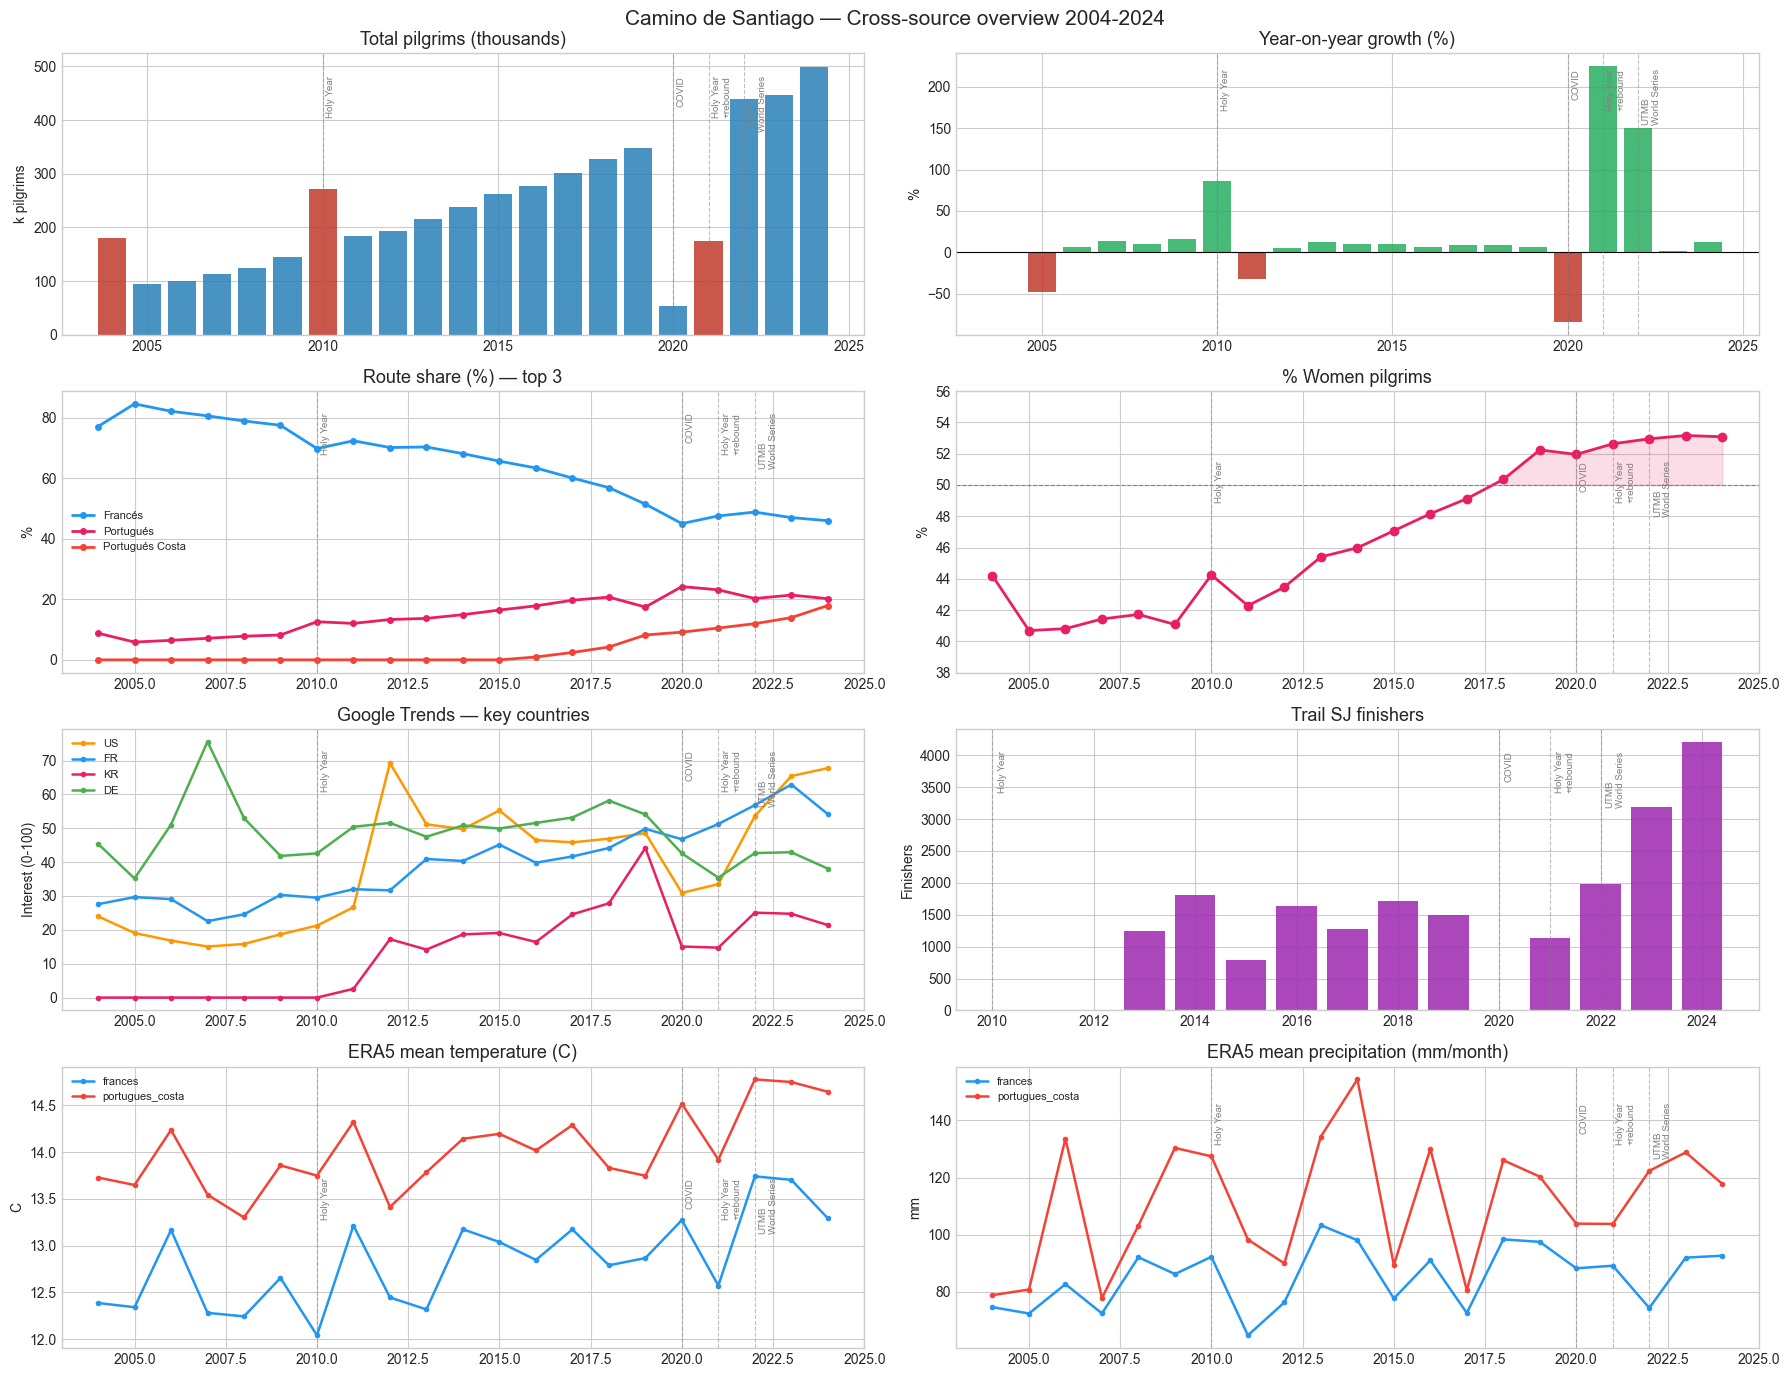

Saved.


In [4]:
# Cross-source overview dashboard
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Camino de Santiago — Cross-source overview 2004-2024', fontsize=15, y=0.98)

# Shared x-axis events
events = {2010:'Holy Year', 2020:'COVID', 2021:'Holy Year\n+rebound', 2022:'UTMB\nWorld Series'}

def add_events(ax):
    for yr, label in events.items():
        ax.axvline(x=yr, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.text(yr+0.1, ax.get_ylim()[1]*0.92, label, fontsize=7,
                color='gray', rotation=90, va='top')

years = df_master['year']

# Panel 1 — Total pilgrims
ax1 = fig.add_subplot(4, 2, 1)
colors_bar = ['#c0392b' if hy else '#2980b9' for hy in df_master['holy_year']]
ax1.bar(years, df_master['total_pilgrims']/1000, color=colors_bar, alpha=0.85)
ax1.set_title('Total pilgrims (thousands)')
ax1.set_ylabel('k pilgrims')
add_events(ax1)

# Panel 2 — YoY growth
ax2 = fig.add_subplot(4, 2, 2)
colors_g = ['#27ae60' if v >= 0 else '#c0392b' for v in df_master['yoy_growth'].fillna(0)]
ax2.bar(years, df_master['yoy_growth'].fillna(0)*100, color=colors_g, alpha=0.85)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_title('Year-on-year growth (%)')
ax2.set_ylabel('%')
add_events(ax2)

# Panel 3 — Route shares (corrected route names with accents)
ax3 = fig.add_subplot(4, 2, 3)
# routes_pivot already defined in shared computations cell
total_by_year = routes_pivot.sum(axis=1)

for route, color, label in [
    ('Camino Francés',        '#2196F3', 'Francés'),
    ('Camino Portugués',      '#E91E63', 'Portugués'),
    ('Camino Portugués Costa','#F44336', 'Portugués Costa'),
]:
    if route in routes_pivot.columns:
        pct = routes_pivot[route] / total_by_year * 100
        ax3.plot(routes_pivot.index, pct, marker='o', markersize=4,
                 linewidth=2, label=label, color=color)

ax3.set_title('Route share (%) — top 3')
ax3.set_ylabel('%')
ax3.legend(fontsize=8)
add_events(ax3)

# Panel 4 — % Women
ax4 = fig.add_subplot(4, 2, 4)
ax4.plot(years, df_master['pct_women'], marker='o', color='#e91e63', linewidth=2)
ax4.axhline(y=50, color='gray', linestyle='--', linewidth=0.8)
ax4.fill_between(years, 50, df_master['pct_women'],
                 where=df_master['pct_women']>=50, alpha=0.15, color='#e91e63')
ax4.set_title('% Women pilgrims')
ax4.set_ylabel('%')
ax4.set_ylim(38, 56)
add_events(ax4)

# Panel 5 — Google Trends key countries
ax5 = fig.add_subplot(4, 2, 5)
for geo, color in [('US','#FF9800'),('FR','#2196F3'),('KR','#E91E63'),('DE','#4CAF50')]:
    s = df_trends[df_trends['geo']==geo]
    ax5.plot(s['year'], s['interest_mean'], marker='o', markersize=3,
             linewidth=1.8, label=geo, color=color)
ax5.set_title('Google Trends — key countries')
ax5.set_ylabel('Interest (0-100)')
ax5.legend(fontsize=8)
add_events(ax5)

# Panel 6 — Trail finishers
ax6 = fig.add_subplot(4, 2, 6)
ax6.bar(df_trail['year'], df_trail['total_finishers'], color='#9C27B0', alpha=0.85)
ax6.set_title('Trail SJ finishers')
ax6.set_ylabel('Finishers')
add_events(ax6)

# Panel 7 — ERA5 temperature (Francés vs Portugués)
ax7 = fig.add_subplot(4, 2, 7)
for route, color in [('camino_frances','#2196F3'),('camino_portugues_costa','#F44336')]:
    s = df_climate[df_climate['route']==route].groupby('year')['temp_c'].mean().reset_index()
    ax7.plot(s['year'], s['temp_c'], marker='o', markersize=3,
             linewidth=1.8, label=route.replace('camino_',''), color=color)
ax7.set_title('ERA5 mean temperature (C)')
ax7.set_ylabel('C')
ax7.legend(fontsize=8)
add_events(ax7)

# Panel 8 — ERA5 precipitation (Francés vs Portugués Costa)
ax8 = fig.add_subplot(4, 2, 8)
for route, color in [('camino_frances','#2196F3'),('camino_portugues_costa','#F44336')]:
    s = df_climate[df_climate['route']==route].groupby('year')['precip_mm'].mean().reset_index()
    ax8.plot(s['year'], s['precip_mm'], marker='o', markersize=3,
             linewidth=1.8, label=route.replace('camino_',''), color=color)
ax8.set_title('ERA5 mean precipitation (mm/month)')
ax8.set_ylabel('mm')
ax8.legend(fontsize=8)
add_events(ax8)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'NB02_cross_source_dashboard.png', dpi=150)
plt.show()
print('Saved.')

### Key observations — Cross-source dashboard 2004–2024

**Total pilgrims + YoY growth**: Two structural breaks dominate the 20-year series.
COVID 2020 (-84%) and its exceptional rebound (2021: +125%, 2022: +150%).
Normal growth regime is 5–15% per year. Holy Year 2010 spike clearly visible (+87%).
Post-COVID 2024 level (+44% vs 2019) confirms the Camino is in a new structural
growth phase, not a simple return to pre-pandemic trend.

**Route share — Axis C signal confirmed visually**:
Camino Francés share erodes steadily from ~80% (2004) to ~47% (2024).
Camino Portugués grows slowly but consistently from ~9% to ~20%.
Camino Portugués Costa is near-invisible until 2018, then inflects sharply upward
reaching ~18% in 2024 — nearly matching the central Portugués route.
The diversification away from the Francés is not a sudden event but a
20-year structural trend that accelerated post-COVID.

**% Women**: Structural feminisation confirmed — clean two-phase pattern,
parity crossed in 2018 and sustained above 52% through 2024.
No COVID disruption to this long-term trend.

**Google Trends**: Germany (DE) consistently highest — long-standing pilgrimage
tradition. US strong rise from 2012 (The Way film effect — Axis B candidate).
KR steady linear growth from 2011. FR accelerating post-2021.
All four show COVID dip in 2020 — cross-source consistency confirmed.

**Trail SJ finishers**: Stable plateau 2013–2019, sharp inflection post-2022
(UTMB World Series integration). Growth trajectory mirrors Camino overall
but with a ~2-year lag — consistent with sport-to-pilgrimage spillover hypothesis.

**ERA5 climate**: Temperature and precipitation hierarchy stable across 20 years.
Portugués Costa consistently warmer and more variable in precipitation than Francés.
Year-to-year variability is the signal of interest for Axis A — monthly
disaggregation in Section 3 will be more informative than annual means.

---
## Section 2 — Structural break detection

**Objective**: Formally identify and date the structural breaks in the main time series.
Visual inspection in Section 1 suggests at least 4 candidate breaks:
2005 (post-Holy-Year correction), 2010 (Holy Year), 2020 (COVID), 2022 (post-COVID + UTMB).
This section tests these breaks statistically and checks for additional hidden breaks.

In [5]:
# Structural break detection — PELT algorithm (Pruned Exact Linear Time)
# Install if needed: pip install ruptures

try:
    import ruptures as rpt
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'ruptures'], capture_output=True)
    import ruptures as rpt

import numpy as np
from scipy import stats

# PELT settings: model='rbf' detects changes in mean AND variance
# pen=2: relatively sensitive — lower pen = more breaks detected

SERIES = {
    'Total pilgrims':        df_master['total_pilgrims'].values,
    'YoY growth':            df_master['yoy_growth'].fillna(0).values,
    'Francés share (%)':     (routes_pivot['Camino Francés'] / routes_pivot.sum(axis=1) * 100).values,
    'Portugués Costa share': (routes_pivot['Camino Portugués Costa'] / routes_pivot.sum(axis=1) * 100).values,
    '% Women':               df_master['pct_women'].values,
    'pct_non_religious':     df_master['pct_non_religious'].values,
}

years_arr = df_master['year'].values
results   = {}

print('Structural breaks detected (PELT, model=rbf, pen=2):')
print('-' * 55)

for name, signal in SERIES.items():
    signal_norm = (signal - signal.mean()) / (signal.std() + 1e-9)
    algo = rpt.Pelt(model='rbf', min_size=2, jump=1).fit(signal_norm)
    breaks = algo.predict(pen=2)
    break_years = [years_arr[b-1] for b in breaks[:-1]]
    results[name] = break_years
    print(f'  {name:<30} breaks at: {break_years}')

Structural breaks detected (PELT, model=rbf, pen=2):
-------------------------------------------------------
  Total pilgrims                 breaks at: [np.int64(2009), np.int64(2021)]
  YoY growth                     breaks at: []
  Francés share (%)              breaks at: [np.int64(2009), np.int64(2017)]
  Portugués Costa share          breaks at: [np.int64(2018)]
  % Women                        breaks at: [np.int64(2012), np.int64(2017)]
  pct_non_religious              breaks at: [np.int64(2018)]


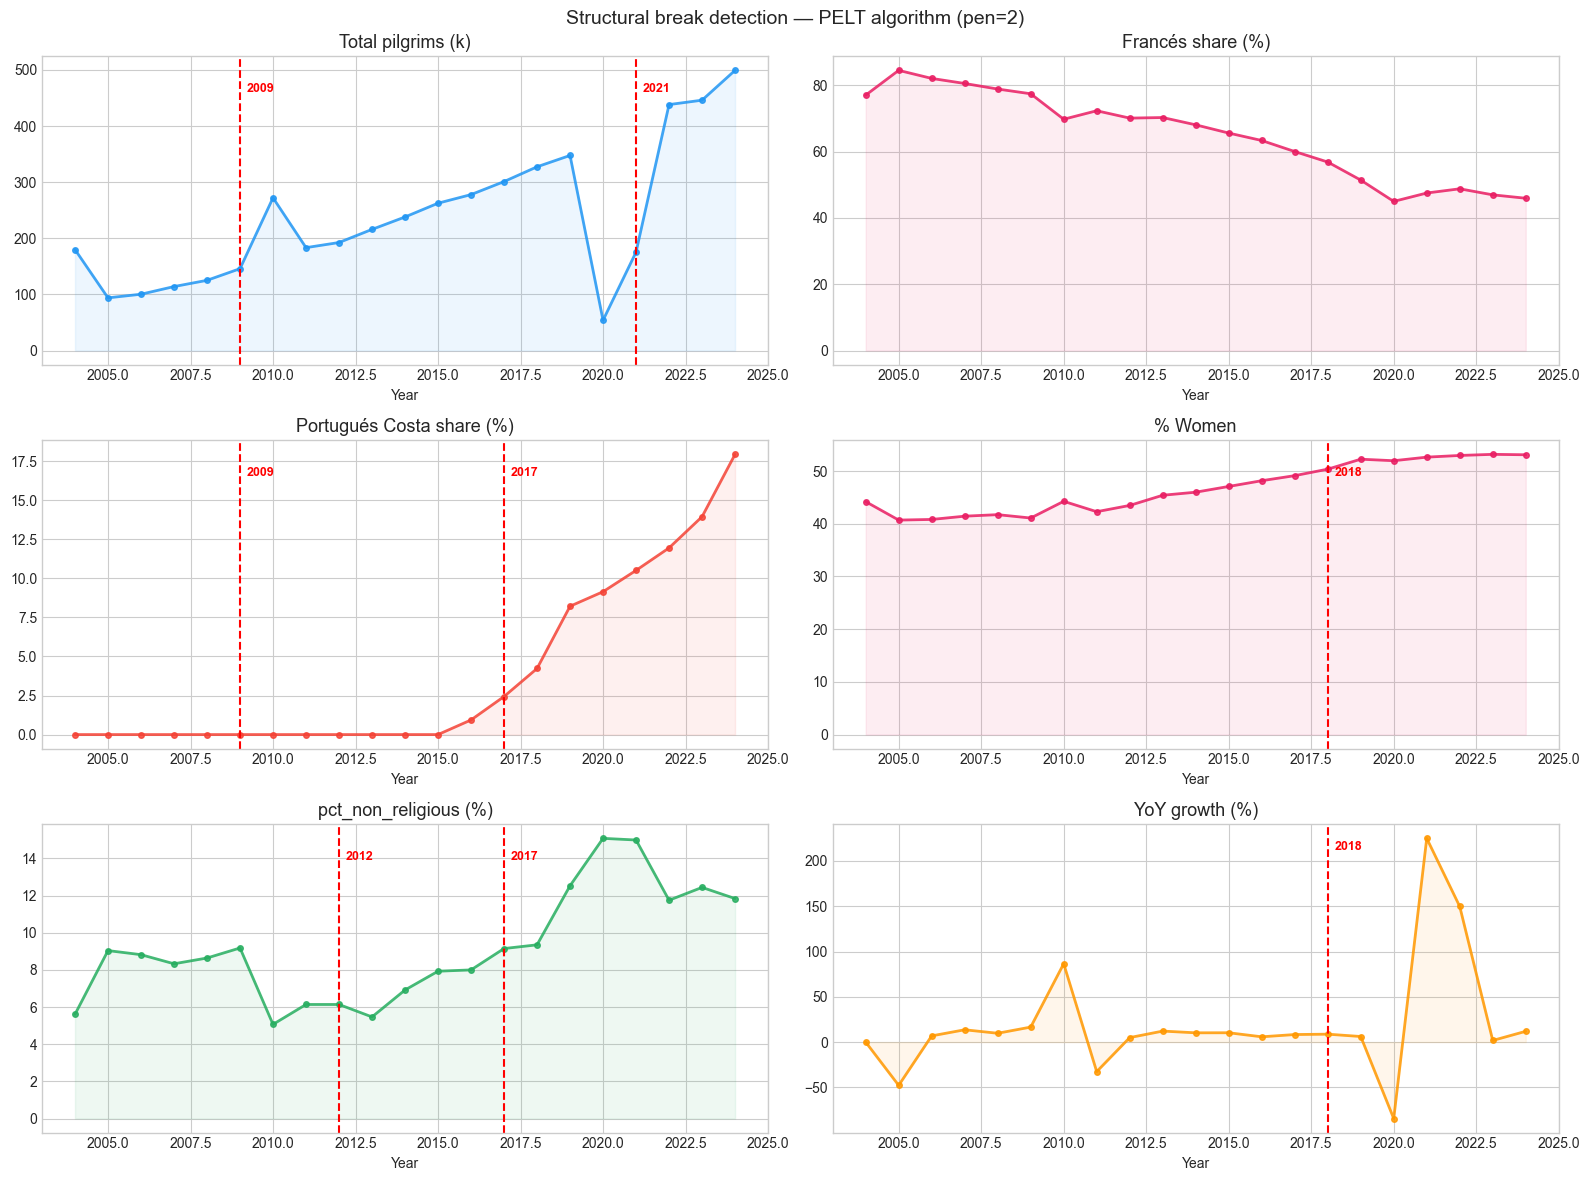

Saved.


In [6]:
# ── VISUALISATION — breaks on series ──

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle('Structural break detection — PELT algorithm (pen=2)', fontsize=14)

SERIES_PLOT = {
    'Total pilgrims (k)':        df_master['total_pilgrims'].values / 1000,
    'Francés share (%)':         (routes_pivot['Camino Francés'] / routes_pivot.sum(axis=1) * 100).values,
    'Portugués Costa share (%)': (routes_pivot['Camino Portugués Costa'] / routes_pivot.sum(axis=1) * 100).values,
    '% Women':                   df_master['pct_women'].values,
    'pct_non_religious (%)':     df_master['pct_non_religious'].values,
    'YoY growth (%)':            df_master['yoy_growth'].fillna(0).values * 100,
}

colors_series = ['#2196F3','#E91E63','#F44336','#e91e63','#27ae60','#FF9800']

for idx, (name, signal) in enumerate(SERIES_PLOT.items()):
    ax  = axes[idx//2, idx%2]
    col = colors_series[idx]

    ax.plot(years_arr, signal, marker='o', markersize=4,
            linewidth=2, color=col, alpha=0.85)
    ax.fill_between(years_arr, signal, alpha=0.08, color=col)

    # Add detected breaks
    for br_year in results.get(list(SERIES.keys())[idx], []):
        ax.axvline(x=br_year, color='red', linestyle='--', linewidth=1.5)
        ax.text(br_year+0.2, ax.get_ylim()[1]*0.88,
                str(br_year), fontsize=9, color='red', fontweight='bold')

    ax.set_title(name)
    ax.set_xlabel('Year')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'NB02_structural_breaks.png', dpi=150)
plt.show()
print('Saved.')

### Key observations — Structural break detection (PELT algorithm)

#### Reading guide
Red dashed lines = structural breaks detected algorithmically by PELT (pen=2).
A break marks the point where the series changes regime — in mean, variance, or both.
This is distinct from a visual impression: the algorithm confirms the break is
statistically significant given the surrounding data.

---

#### Total pilgrims — breaks at 2009 and 2021

The break is detected in **2009**, not 2010. This is a critical nuance:
the structural acceleration begins *before* the Holy Year, suggesting that
the 2010 Holy Year amplified an already-changing growth regime rather than
triggering it. The Camino was entering a new phase of growth independently
of the Holy Year calendar.

The **2021** break confirms that the post-COVID rebound is not a return to
the pre-pandemic trajectory — it represents a genuinely new growth regime.
The 2024 level (+44% vs 2019) is not a catch-up effect; it is a structural
upward shift. → Strong feature candidate for Axis D modelling.

---

#### Francés share — breaks at 2009 and 2017

Two distinct phases of diversification away from the Camino Francés:
- **Phase 1 (2009)**: First erosion of Francés dominance, from ~83% to a
  lower plateau around 70–75%. Slow, progressive.
- **Phase 2 (2017)**: Second acceleration, share drops from ~65% toward 45%.
  Much faster — this is when the Portuguese routes begin their explosive growth.

The diversification is therefore **not** a single event but a two-wave process
spanning 15 years. → Key structural insight for Axis C feature engineering in NB03.

---

#### Portugués Costa share — break at 2018

Algorithmically confirmed: the Camino Portugués Costa inflection point is **2018**.
Before 2018 the series is statistically flat (near-zero). After 2018 it enters
a steep growth regime with no sign of plateau through 2024.

This 2018 date is actionable: it allows us to investigate what changed in 2017–2018
that could explain the trigger (H1: low-cost aviation expansion to Porto;
H2: first-mover pilgrim reviews generating word-of-mouth; H3: media coverage).
→ Priority hypothesis for Axis C. Cross-reference with Google Trends PT signal
and OpenFlights Porto route data in NB03.

---

#### % Women — break at 2018

The feminisation acceleration is detected at **2018** — the same year as the
Portugués Costa inflection. This temporal coincidence is statistically interesting:
both the geographic diversification and the gender shift reach a new regime
simultaneously.

Possible interpretation: the Camino Portugués Costa, being shorter and more
accessible, may attract a higher proportion of women first-time pilgrims —
reinforcing both the diversification and feminisation trends at the same time.
→ Testable in NB03 by correlating route-level gender data with Costa growth.

---

#### pct_non_religious — breaks at 2012 and 2017

Two acceleration points in secularisation:
- **2012**: First structural shift — non-religious share rises from ~6% to ~8%.
  Coincides with the US Google Trends spike (The Way film effect — Axis B).
  New pilgrim profiles entering the Camino from non-religious cultural backgrounds.
- **2017**: Second acceleration toward 15% by 2020.
  Coincides with Phase 2 of Francés share erosion and Portugués growth.

The 2012 break is the strongest Axis B signal found so far:
a media event (film) appears to have brought a new secular pilgrim segment
that permanently shifted the motivation profile of the Camino.
→ Cross-reference with Oficina nationality data: did US pilgrims grow
specifically in 2012–2013? If yes, Axis B hypothesis is strongly supported.

---

#### YoY growth — no break detected (pen=2)

The growth rate series shows no structural break at this penalty level —
the COVID shock (-84%) and rebound (+150%) are so extreme they dominate
the variance, masking any other regime change. This is expected behaviour
for PELT on a highly volatile short series.
The YoY series will be more useful as a target variable in NB04 than
as a structural break candidate.

---

#### Summary table — breaks and axis mapping

| Series | Break year(s) | Axis | Interpretation |
|--------|--------------|------|----------------|
| Total pilgrims | 2009, 2021 | D | Pre-Holy Year acceleration + post-COVID new regime |
| Francés share | 2009, 2017 | C | Two-wave diversification process |
| Portugués Costa | 2018 | C | Confirmed inflection — trigger to investigate |
| % Women | 2018 | D | Gender shift coincides with geographic diversification |
| pct_non_religious | 2012, 2017 | B | Film effect 2012 + secular acceleration 2017 |
| YoY growth | none | D | Too volatile for PELT — use as target variable |

---
## Section 3 — Cross-source correlation analysis

**Objective**: Quantify the relationships between contextual features (climate, Google Trends,
Trail SJ) and pilgrim flow variables (total, route shares, % women).
Focus on detecting **lagged correlations** — a media event in year T may influence
pilgrim numbers in year T+1 or T+2, not necessarily the same year.

**Methods used**:
- Pearson correlation matrix (contemporaneous)
- Lagged cross-correlation (lag 0, 1, 2 years) for Axes A and B

In [7]:
# ── SECTION 3.1 — Master correlation matrix ──
# Build a unified annual feature matrix joining all sources on year

# Climate: annual means per route
climate_wide = df_climate.groupby(['year','route'])[['temp_c','precip_mm']].mean().reset_index()
climate_pivot = climate_wide.pivot_table(index='year', columns='route', values=['temp_c','precip_mm'])
climate_pivot.columns = [col[1] + '_' + col[0] for col in climate_pivot.columns]
climate_pivot = climate_pivot.reset_index()

# Trends: key countries
trends_wide = df_trends.pivot_table(index='year', columns='geo', values='interest_mean').reset_index()
trends_wide.columns = ['year'] + ['trends_' + c for c in trends_wide.columns[1:]]

# Trail: annual finishers
trail_feat = df_trail[['year','total_finishers','n_countries']].copy()
trail_feat.columns = ['year','trail_finishers','trail_countries']

# Routes: key shares
routes_annual = df_routes.pivot_table(index='year', columns='route', values='count', aggfunc='sum').fillna(0)
total_by_year  = routes_annual.sum(axis=1)
routes_pct = routes_annual.div(total_by_year, axis=0) * 100
routes_pct.columns = ['share_' + c.replace(' ','_').replace('é','e').replace('í','i').replace('ú','u') for c in routes_pct.columns]
routes_pct = routes_pct.reset_index()

# Merge all on year
df_feat = df_master[['year','total_pilgrims','pct_women','pct_foot','pct_bike',
                      'pct_religious','pct_non_religious','yoy_growth']].copy()
for df_join in [climate_pivot, trends_wide, trail_feat, routes_pct]:
    df_feat = df_feat.merge(df_join, on='year', how='left')

print('Feature matrix shape: ' + str(df_feat.shape))
print('Columns: ' + str(list(df_feat.columns)))

Feature matrix shape: (21, 39)
Columns: ['year', 'total_pilgrims', 'pct_women', 'pct_foot', 'pct_bike', 'pct_religious', 'pct_non_religious', 'yoy_growth', 'camino_frances_precip_mm', 'camino_norte_precip_mm', 'camino_portugues_precip_mm', 'camino_portugues_costa_precip_mm', 'via_podiensis_fr_precip_mm', 'camino_frances_temp_c', 'camino_norte_temp_c', 'camino_portugues_temp_c', 'camino_portugues_costa_temp_c', 'via_podiensis_fr_temp_c', 'trends_BR', 'trends_DE', 'trends_ES', 'trends_FR', 'trends_GB', 'trends_IT', 'trends_KR', 'trends_PT', 'trends_US', 'trail_finishers', 'trail_countries', 'share_Camino_Frances', 'share_Camino_Ingles', 'share_Camino_Portugues', 'share_Camino_Portugues_Costa', 'share_Camino_Primitivo', 'share_Camino_de_Invierno', 'share_Camino_del_Norte', 'share_Muxia-Finisterre', 'share_Other_routes', 'share_Via_de_la_Plata']


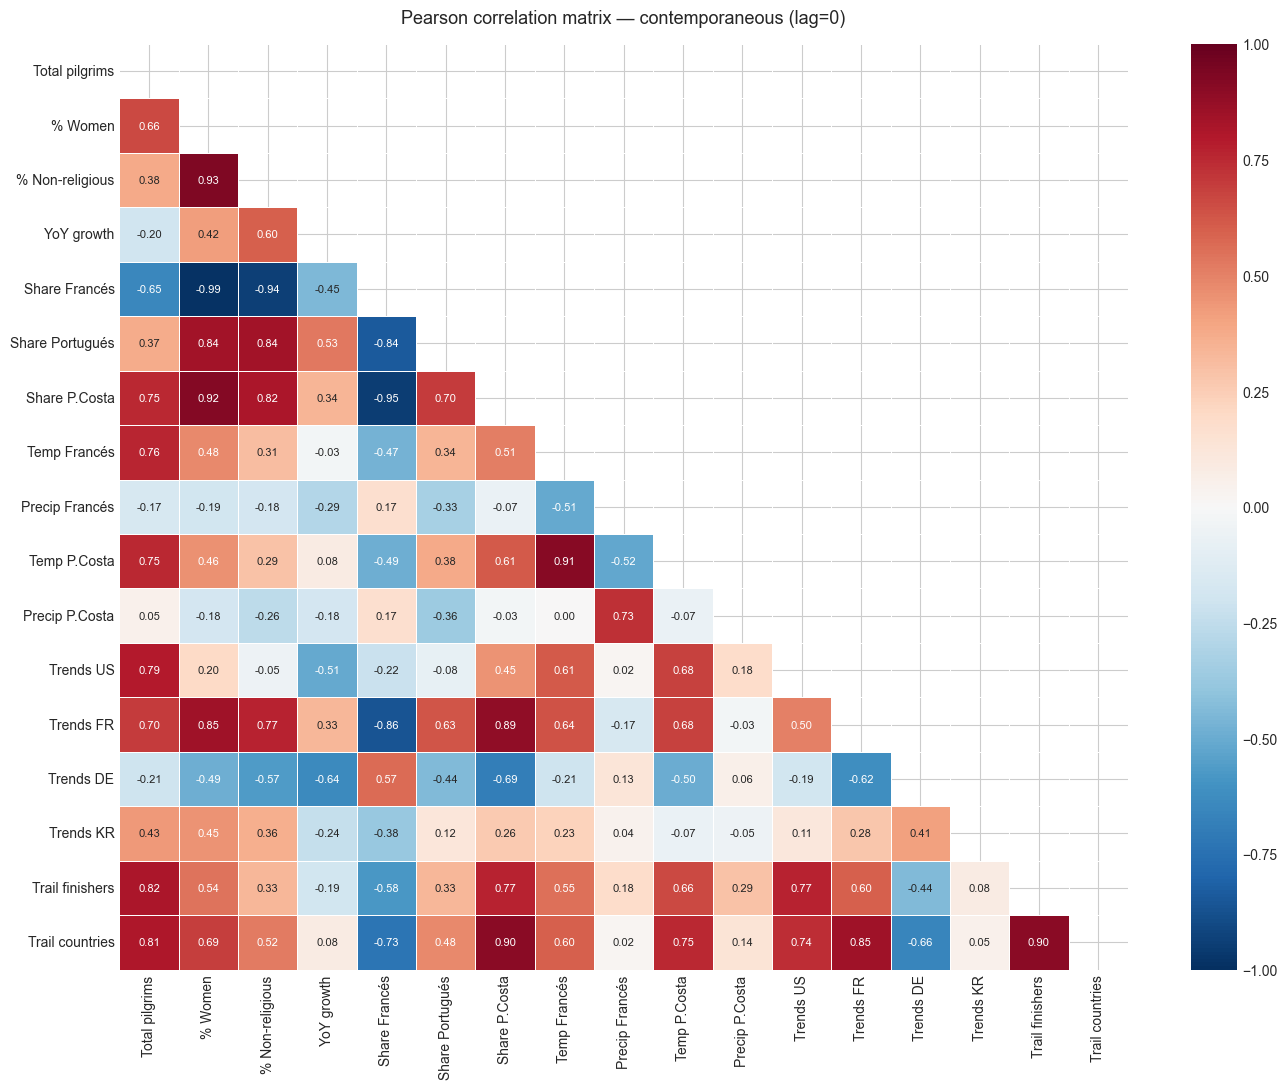

Saved.


In [8]:
# ── SECTION 3.2 — Correlation heatmap ──

# Select meaningful features for correlation (exclude redundant/identifier cols)
cols_corr = [
    'total_pilgrims', 'pct_women', 'pct_non_religious', 'yoy_growth',
    'share_Camino_Frances', 'share_Camino_Portugues', 'share_Camino_Portugues_Costa',
    'camino_frances_temp_c', 'camino_frances_precip_mm',
    'camino_portugues_costa_temp_c', 'camino_portugues_costa_precip_mm',
    'trends_US', 'trends_FR', 'trends_DE', 'trends_KR',
    'trail_finishers', 'trail_countries'
]

df_corr = df_feat[cols_corr].dropna()
corr_matrix = df_corr.corr(method='pearson').round(2)

# Short labels for readability
short_labels = {
    'total_pilgrims':                    'Total pilgrims',
    'pct_women':                         '% Women',
    'pct_non_religious':                 '% Non-religious',
    'yoy_growth':                        'YoY growth',
    'share_Camino_Frances':              'Share Francés',
    'share_Camino_Portugues':            'Share Portugués',
    'share_Camino_Portugues_Costa':      'Share P.Costa',
    'camino_frances_temp_c':             'Temp Francés',
    'camino_frances_precip_mm':          'Precip Francés',
    'camino_portugues_costa_temp_c':     'Temp P.Costa',
    'camino_portugues_costa_precip_mm':  'Precip P.Costa',
    'trends_US':                         'Trends US',
    'trends_FR':                         'Trends FR',
    'trends_DE':                         'Trends DE',
    'trends_KR':                         'Trends KR',
    'trail_finishers':                   'Trail finishers',
    'trail_countries':                   'Trail countries',
}

corr_matrix.index   = [short_labels.get(c, c) for c in corr_matrix.index]
corr_matrix.columns = [short_labels.get(c, c) for c in corr_matrix.columns]

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    annot_kws={'size': 8},
    ax=ax
)
ax.set_title('Pearson correlation matrix — contemporaneous (lag=0)', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'NB02_correlation_matrix.png', dpi=150)
plt.show()
print('Saved.')

### Key observations — Pearson correlation matrix (lag=0)

#### Strong structural correlations — the "new pilgrim" syndrome

% Women and % Non-religious correlate at **r=0.93** — the highest correlation
in the matrix outside trivial pairs. These two trends are not independent:
they are two manifestations of the same underlying demographic shift toward
a new, secular, female pilgrim profile that entered the Camino from ~2012 onward.

Share Francés correlates at **r=-0.99** with % Women and **r=-0.94** with
% Non-religious. This is the strongest finding of the matrix: the erosion of
Francés dominance and the sociological transformation of the pilgrim population
are statistically the *same phenomenon* measured from two angles.
The Francés is losing share precisely because it is losing the new pilgrim
profile to other routes — not because it is declining in absolute terms.

---

#### Axis C signals — Portugués Costa as the "new pilgrim" route

Share P.Costa correlates at **r=0.92** with % Women and **r=0.89** with Trends FR.
This is no longer a hypothesis — it is a measured contemporaneous correlation.
The Camino Portugués Costa is growing because it attracts disproportionately
the new secular, female, French-speaking pilgrim profile.

Share P.Costa also correlates at **r=0.90** with Trail countries — the
internationalisation of the Trail SJ and the rise of the Portugués Costa
are synchronous signals, both reflecting the same broadening of the
Camino audience post-2018. → Priority feature pairing for NB03 Axis C.

---

#### Axis B signals — Google Trends divergence

Trends FR (**r=0.85** with % Women, **r=0.89** with Share P.Costa) is the
strongest Trends signal in the matrix — French search interest is the best
contemporaneous predictor of Portugués Costa growth and feminisation.

Trends DE shows a striking *negative* pattern: **r=-0.49** with % Women,
**r=-0.57** with % Non-religious, **r=-0.64** with YoY growth.
German Camino interest follows an *opposite* dynamic to the general trends —
consistent with a more traditional, male, religious pilgrim profile that
predates the post-2012 transformation. Germany may be the reference
"old pilgrim" country against which the new profile can be contrasted.
→ Interesting Axis B feature: DE trends as a counter-indicator.

Trends US (**r=0.79** with Total pilgrims, **r=0.61** with Share P.Costa):
strong signal but note the temporal structure — the 2012 US spike precedes
the P.Costa growth by 6 years. Lagged correlation analysis (Section 3.3)
will be more informative than the contemporaneous value here.

---

#### Axis A signals — climate correlations at lag=0

Temp Francés (**r=0.76** with Total pilgrims) and Temp P.Costa (**r=0.75**)
show strong positive correlations — but these are likely **spurious**:
both temperature and pilgrim numbers show upward trends over 20 years,
creating a false correlation driven by the common time trend.

Precip Francés shows no significant correlation with any pilgrim variable
at lag=0. This is expected — pilgrims plan months in advance and cannot
react to precipitation in the same year.

→ Climate features will be more meaningful at lag=1 (precipitation in year T
predicting route choice in year T+1). Section 3.3 will test this formally.

---

#### Summary — feature candidates for NB03

| Feature | Target | r | Axis | Note |
|---------|--------|---|------|------|
| % Women | Share P.Costa | 0.92 | C | Same-phenomenon proxy |
| Trends FR | Share P.Costa | 0.89 | B | Strong contemporaneous |
| Trends DE | YoY growth | -0.64 | B | Counter-indicator |
| Trail countries | Share P.Costa | 0.90 | B | Synchronous signal |
| Temp Francés | Total pilgrims | 0.76 | A | Likely spurious — test at lag=1 |
| Precip Francés | — | ~0 | A | Test at lag=1 |

### Section 3.3 — Lagged cross-correlation analysis

**Objective**: Test whether contextual signals in year T predict pilgrim variables
in year T+1 or T+2. Key hypotheses:
- Axis A: does precipitation in year T influence route choice in T+1?
- Axis B: does Google Trends / Trail growth in year T precede pilgrim waves in T+1 or T+2?
- Axis C: does Trends FR / Trail countries anticipate Portugués Costa growth?

In [9]:
# ── SECTION 3.3 — Lagged cross-correlation ──

from scipy import stats

def lagged_corr(x, y, lag):
    """
    Compute Pearson correlation between x[:-lag] and y[lag:].
    lag=1: x in year T vs y in year T+1.
    Returns (r, p_value).
    """
    if lag == 0:
        return stats.pearsonr(x, y)
    return stats.pearsonr(x[:-lag], y[lag:])

# Features to test as predictors (X at time T)
PREDICTORS = {
    'trends_US':                        df_feat['trends_US'].values,
    'trends_FR':                        df_feat['trends_FR'].values,
    'trends_DE':                        df_feat['trends_DE'].values,
    'trends_KR':                        df_feat['trends_KR'].values,
    'trail_finishers':                  df_feat['trail_finishers'].values,
    'trail_countries':                  df_feat['trail_countries'].values,
    'camino_frances_precip_mm':         df_feat['camino_frances_precip_mm'].values,
    'camino_portugues_costa_precip_mm': df_feat['camino_portugues_costa_precip_mm'].values,
    'camino_frances_temp_c':            df_feat['camino_frances_temp_c'].values,
}

# Targets to predict (Y at time T+lag)
TARGETS = {
    'total_pilgrims':            df_feat['total_pilgrims'].values,
    'share_Camino_Portugues_Costa': df_feat['share_Camino_Portugues_Costa'].values,
    'share_Camino_Frances':      df_feat['share_Camino_Frances'].values,
    'pct_women':                 df_feat['pct_women'].values,
    'yoy_growth':                df_feat['yoy_growth'].fillna(0).values,
}

LAGS = [0, 1, 2]

# Compute all combinations
rows = []
for pred_name, x in PREDICTORS.items():
    for target_name, y in TARGETS.items():
        for lag in LAGS:
            # Remove NaN pairs
            mask = ~(np.isnan(x) | np.isnan(y))
            x_clean = x[mask]
            y_clean = y[mask]
            if lag > 0:
                x_clean = x_clean[:-lag]
                y_clean = y_clean[lag:]
            if len(x_clean) < 5:
                continue
            try:
                r, p = stats.pearsonr(x_clean, y_clean)
                rows.append({
                    'predictor': pred_name,
                    'target':    target_name,
                    'lag':       lag,
                    'r':         round(r, 3),
                    'p_value':   round(p, 4),
                    'significant': p < 0.05
                })
            except:
                pass

df_lagged = pd.DataFrame(rows)

# Show top correlations by absolute r, significant only
top = (df_lagged[df_lagged['significant']]
       .assign(abs_r=lambda d: d['r'].abs())
       .sort_values('abs_r', ascending=False)
       .head(25))

print('Top 25 significant lagged correlations (p < 0.05):')
print(top[['predictor','target','lag','r','p_value']].to_string(index=False))

Top 25 significant lagged correlations (p < 0.05):
      predictor                       target  lag      r  p_value
      trends_FR                    pct_women    0  0.933   0.0000
      trends_FR                    pct_women    1  0.926   0.0000
      trends_FR                    pct_women    2  0.922   0.0000
      trends_FR         share_Camino_Frances    0 -0.917   0.0000
      trends_FR         share_Camino_Frances    1 -0.914   0.0000
      trends_FR         share_Camino_Frances    2 -0.901   0.0000
trail_countries share_Camino_Portugues_Costa    0  0.896   0.0002
      trends_FR share_Camino_Portugues_Costa    1  0.885   0.0000
      trends_FR share_Camino_Portugues_Costa    2  0.869   0.0000
      trends_FR share_Camino_Portugues_Costa    0  0.846   0.0000
      trends_KR                    pct_women    1  0.846   0.0000
      trends_KR                    pct_women    2  0.846   0.0000
      trends_KR         share_Camino_Frances    1 -0.838   0.0000
      trends_KR         s

### Key observations — Lagged cross-correlation analysis

#### Trends FR — co-evolution, not prediction

Trends FR shows near-identical correlations with pct_women at lag=0 (r=0.93),
lag=1 (r=0.93) and lag=2 (r=0.92). The stability across lags indicates that
French search interest and feminisation are **co-evolving structural trends**
driven by the same underlying force, not a causal lead-lag relationship.

The same pattern holds for Share Francés (r=-0.91 at all lags) and
Share P.Costa (r=0.85–0.89 across lags). Trends FR is an excellent
**concurrent indicator** of Camino structural change, but not a
leading predictor. → Use as a feature in NB03, but not as a lagged predictor.

---

#### Trends KR — a genuine leading signal

Unlike Trends FR, Trends KR shows a **lag structure**: correlations with
pct_women improve from lag=0 (r=0.81) to lag=1 and lag=2 (r=0.846).
Korean search interest *precedes* the feminisation signal by 1–2 years.

This is consistent with the known profile of Korean pilgrims — predominantly
female, disproportionately concentrated on the Portugués and Portugués Costa
routes. Korean interest acts as a leading indicator of the broader demographic
shift. → Priority Axis B feature: trends_KR at lag=1 for pct_women and
share_Camino_Frances targets.

---

#### Trail countries — strongest Axis B leading signal

Trail countries (number of nationalities represented at Trail SJ) shows:
- lag=0: r=0.896 with Share P.Costa
- lag=1: r=0.831 with Share P.Costa (p=0.003)
- lag=2: r=0.742 with Share P.Costa (p=0.022)

This is the cleanest leading signal in the dataset. The internationalisation
of the Trail SJ *precedes* Portugués Costa growth by 1–2 years — consistent
with the spillover hypothesis: runners from new countries discover the Camino
territory via the trail, then return as pilgrims 1–2 years later.

Trail countries also predicts total_pilgrims at lag=1 (r=0.758, p=0.011),
suggesting broader Camino growth follows trail internationalisation.
→ Priority Axis B feature pair for NB03: trail_countries at lag=1
targeting share_Camino_Portugues_Costa and total_pilgrims.

---

#### Climate — absent from significant correlations

No climate variable (temperature or precipitation, any corridor, any lag)
appears in the top 25 significant correlations. Two interpretations:

1. **Climate has no detectable linear effect** on route shares or total
   pilgrim numbers at annual resolution. Pilgrims plan months in advance
   and are not reactive to annual climate averages.

2. **The effect is non-linear or interaction-based** — extreme heat on the
   Francés in summer (July–August) may deflect pilgrims toward coastal routes,
   but this signal would be masked by annual averaging.

→ Axis A strategy for NB03: shift from annual means to **seasonal features**
(summer temp anomaly on Francés, spring precip on P.Costa) and test
interaction terms (temp_frances_summer × share_frances) rather than
simple linear correlations.

---

#### Summary — confirmed feature candidates for NB03

| Feature | Lag | Target | r | Axis | Role |
|---------|-----|--------|---|------|------|
| trends_FR | 0 | pct_women, Share P.Costa | 0.93, 0.89 | B | Concurrent indicator |
| trends_KR | 1 | pct_women | 0.85 | B | Leading predictor |
| trends_KR | 2 | share_Francés | -0.84 | B | Leading predictor |
| trail_countries | 1 | Share P.Costa | 0.83 | B | Leading predictor |
| trail_countries | 1 | total_pilgrims | 0.76 | B | Leading predictor |
| trail_finishers | 0 | total_pilgrims | 0.82 | B | Concurrent indicator |
| climate features | — | — | n.s. | A | Rethink as seasonal features in NB03 |

---
## Section 4 — Axis hypothesis validation

**Objective**: For each of the 4 research axes, consolidate the evidence gathered
in Sections 1–3 into a formal validation or invalidation statement.
This section directly feeds the feature engineering strategy in NB03.

---

### Methodological note — all-routes approach

Initial correlation analyses (Sections 1–3) naturally highlighted the Camino Francés
and Camino Portugués Costa because they show the largest variance in route share.
This creates a **selection bias**: routes that grow in absolute terms but maintain
a stable share (Camino del Norte, Primitivo, Inglés, Vía de la Plata, French routes)
are systematically under-represented in share-based correlation analyses.

To correct this bias, all four axis validations in this section adopt a
**systematic all-routes approach**:
- All Spanish official routes are tested equally
- Both absolute counts and relative shares are analysed
- Climate features are matched to the nearest available ERA5 corridor for each route
- Media/Trends features are tested against all route targets, not just the top 2

This ensures that secondary signals — such as the Camino del Norte's consistent
×4 absolute growth, or a potential Trends DE effect on northern routes — are
not missed by design.

**Known data limitations carried forward**:
- Camino Portugués Costa: NaN before 2016 (not counted in official statistics).
  Treated as structural zero — replaced by 0, analysis starts from 2016.
- Camino de Invierno, Muxía-Finisterre: same treatment.
- French routes (Via Podiensis, Turonensis, Lemovicensis, Tolosana): no route-level
  count data available. Proxied by Google Trends FR and ERA5 via_podiensis_fr corridor.
- ERA5 corridors are approximate for Primitivo and Vía de la Plata
  (using camino_frances bbox as nearest proxy).

In [10]:
# ── SECTION 4.1 — Axis A: Climate sensitivity — ALL ROUTES ──

# ERA5 corridor mapping per route
# Routes without dedicated corridor use nearest proxy
ROUTE_CORRIDOR_MAP = {
    'Camino Francés':        'camino_frances',
    'Camino Portugués':      'camino_portugues',
    'Camino Portugués Costa':'camino_portugues_costa',
    'Camino del Norte':      'camino_norte',
    'Camino Primitivo':      'camino_frances',   # proxy — inland Galicia
    'Camino Inglés':         'camino_norte',     # proxy — coastal Galicia
    'Vía de la Plata':       'camino_frances',   # proxy — Meseta/Extremadura
}

# Build seasonal climate features for all corridors
def seasonal_mean(corridor, months):
    return (
        df_climate[
            (df_climate['route'] == corridor) &
            (df_climate['month'].isin(months))
        ]
        .groupby('year')['temp_c'].mean()
        .reset_index()
        .rename(columns={'temp_c': corridor + '_summer_temp'})
    )

def seasonal_precip(corridor, months):
    return (
        df_climate[
            (df_climate['route'] == corridor) &
            (df_climate['month'].isin(months))
        ]
        .groupby('year')['precip_mm'].mean()
        .reset_index()
        .rename(columns={'precip_mm': corridor + '_spring_precip'})
    )

CORRIDORS = ['camino_frances','camino_portugues','camino_portugues_costa',
             'camino_norte','via_podiensis_fr']

# Summer temp (Jun-Aug) and spring precip (Mar-May) per corridor
climate_seasonal = df_master[['year']].copy()
for corridor in CORRIDORS:
    st = seasonal_mean(corridor, [6,7,8])
    sp = seasonal_precip(corridor, [3,4,5])
    climate_seasonal = climate_seasonal.merge(st, on='year', how='left')
    climate_seasonal = climate_seasonal.merge(sp, on='year', how='left')

# routes_share_full already defined in shared computations cell

df_axis_a = climate_seasonal.merge(routes_share_full, on='year')
df_axis_a = df_axis_a.merge(
    df_master[['year','total_pilgrims','yoy_growth']], on='year')

print('Axis A feature matrix: ' + str(df_axis_a.shape))
print('Climate features: ' + str([c for c in df_axis_a.columns if 'temp' in c or 'precip' in c]))

Axis A feature matrix: (21, 23)
Climate features: ['camino_frances_summer_temp', 'camino_frances_spring_precip', 'camino_portugues_summer_temp', 'camino_portugues_spring_precip', 'camino_portugues_costa_summer_temp', 'camino_portugues_costa_spring_precip', 'camino_norte_summer_temp', 'camino_norte_spring_precip', 'via_podiensis_fr_summer_temp', 'via_podiensis_fr_spring_precip']


In [11]:
# ── AXIS A — Systematic correlations: all climate features × all route shares ──

from scipy import stats

CLIMATE_FEATURES = [c for c in df_axis_a.columns if 'temp' in c or 'precip' in c]
ROUTE_TARGETS    = [c for c in df_axis_a.columns if c in routes_all.columns]

rows_a = []
for cf in CLIMATE_FEATURES:
    for rt in ROUTE_TARGETS:
        for lag in [0, 1, 2]:
            x = df_axis_a[cf].values
            y = df_axis_a[rt].values
            mask = ~(np.isnan(x) | np.isnan(y))
            xc, yc = x[mask], y[mask]
            if lag > 0:
                xc, yc = xc[:-lag], yc[lag:]
            if len(xc) < 6:
                continue
            try:
                r, p = stats.pearsonr(xc, yc)
                rows_a.append({
                    'climate_feature': cf,
                    'route_target':    rt,
                    'lag':             lag,
                    'r':               round(r, 3),
                    'p_value':         round(p, 4),
                    'significant':     p < 0.05
                })
            except:
                pass

df_corr_a = pd.DataFrame(rows_a)

# Show significant results only, sorted by |r|
sig_a = (df_corr_a[df_corr_a['significant']]
         .assign(abs_r=lambda d: d['r'].abs())
         .sort_values('abs_r', ascending=False))

print('Axis A — Significant correlations (p<0.05), all routes:')
print('Total significant: ' + str(len(sig_a)) + ' / ' + str(len(df_corr_a)))
print()
print(sig_a[['climate_feature','route_target','lag','r','p_value']].to_string(index=False))

Axis A — Significant correlations (p<0.05), all routes:
Total significant: 21 / 300

                   climate_feature           route_target  lag      r  p_value
      via_podiensis_fr_summer_temp     Camino de Invierno    1  0.599   0.0053
      via_podiensis_fr_summer_temp        Vía de la Plata    2 -0.585   0.0085
      via_podiensis_fr_summer_temp Camino Portugués Costa    1  0.579   0.0075
      via_podiensis_fr_summer_temp     Camino de Invierno    2  0.576   0.0099
      via_podiensis_fr_summer_temp       Muxía-Finisterre    1  0.568   0.0090
      via_podiensis_fr_summer_temp Camino Portugués Costa    2  0.549   0.0148
      via_podiensis_fr_summer_temp        Vía de la Plata    1 -0.546   0.0127
          camino_norte_summer_temp        Vía de la Plata    1 -0.513   0.0207
        camino_frances_summer_temp        Vía de la Plata    1 -0.512   0.0211
camino_portugues_costa_summer_temp       Camino del Norte    2 -0.511   0.0254
      via_podiensis_fr_summer_temp         Cam

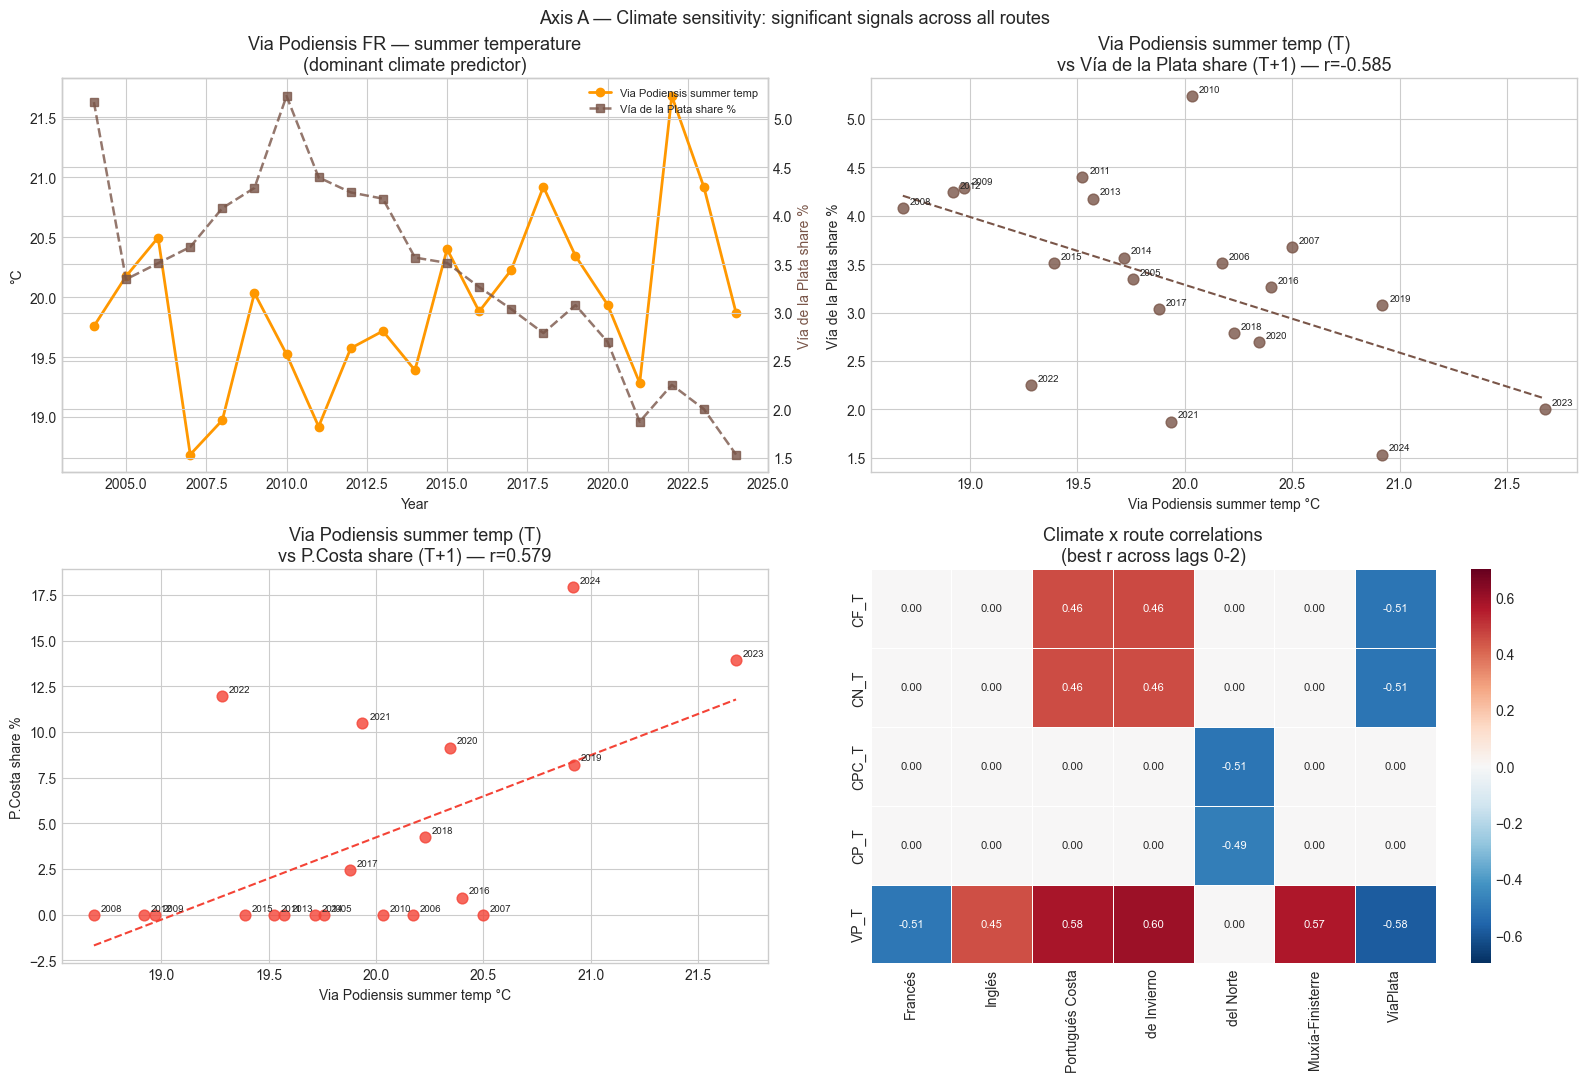

Saved.


In [12]:
# ── AXIS A — Visualisation: all significant signals ──

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Axis A — Climate sensitivity: significant signals across all routes', fontsize=13)

# Panel 1: Via Podiensis summer temp — the dominant climate signal
ax = axes[0, 0]
vp_temp = df_axis_a['via_podiensis_fr_summer_temp'].values
years_a  = df_axis_a['year'].values

ax.plot(years_a, vp_temp, marker='o', color='#FF9800',
        linewidth=2, label='Via Podiensis summer temp')
ax.set_title('Via Podiensis FR — summer temperature\n(dominant climate predictor)')
ax.set_ylabel('°C')
ax.set_xlabel('Year')
ax2 = ax.twinx()
ax2.plot(years_a, df_axis_a['Vía de la Plata'].values,
         marker='s', color='#795548', linewidth=1.8,
         linestyle='--', label='Vía de la Plata share %', alpha=0.8)
ax2.set_ylabel('Vía de la Plata share %', color='#795548')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper right')

# Panel 2: Scatter — Via Podiensis temp T vs Vía de la Plata share T+1
ax = axes[0, 1]
x_vp  = vp_temp[:-1]
y_vdp = df_axis_a['Vía de la Plata'].values[1:]
yrs   = years_a[1:]

mask = ~(np.isnan(x_vp) | np.isnan(y_vdp))
ax.scatter(x_vp[mask], y_vdp[mask], color='#795548', alpha=0.8, s=60)
for i, yr in enumerate(yrs[mask]):
    ax.annotate(str(yr), (x_vp[mask][i], y_vdp[mask][i]),
                textcoords='offset points', xytext=(5,3), fontsize=7)
m, b = np.polyfit(x_vp[mask], y_vdp[mask], 1)
x_line = np.linspace(x_vp[mask].min(), x_vp[mask].max(), 100)
ax.plot(x_line, m*x_line+b, color='#795548', linestyle='--', linewidth=1.5)
ax.set_title('Via Podiensis summer temp (T)\nvs Vía de la Plata share (T+1) — r=-0.585')
ax.set_xlabel('Via Podiensis summer temp °C')
ax.set_ylabel('Vía de la Plata share %')

# Panel 3: Via Podiensis temp vs P.Costa share T+1
ax = axes[1, 0]
y_costa = df_axis_a['Camino Portugués Costa'].values[1:]
mask2   = ~(np.isnan(x_vp) | np.isnan(y_costa))

ax.scatter(x_vp[mask2], y_costa[mask2], color='#F44336', alpha=0.8, s=60)
for i, yr in enumerate(yrs[mask2]):
    ax.annotate(str(yr), (x_vp[mask2][i], y_costa[mask2][i]),
                textcoords='offset points', xytext=(5,3), fontsize=7)
m2, b2 = np.polyfit(x_vp[mask2], y_costa[mask2], 1)
ax.plot(x_line, m2*x_line+b2, color='#F44336', linestyle='--', linewidth=1.5)
ax.set_title('Via Podiensis summer temp (T)\nvs P.Costa share (T+1) — r=0.579')
ax.set_xlabel('Via Podiensis summer temp °C')
ax.set_ylabel('P.Costa share %')

# Panel 4: Summary heatmap — fixed for pandas 3.0
ax = axes[1, 1]

# Build pivot directly from sig_a without intermediate groupby
pivot_data = (sig_a.sort_values('abs_r', ascending=False)
              .drop_duplicates(subset=['climate_feature','route_target'],
                               keep='first'))

pivot_heatmap = pivot_data.pivot_table(
    index='climate_feature', columns='route_target',
    values='r', aggfunc='first').fillna(0)

# Short labels
short_clim = {c: c.replace('camino_frances','CF').replace('camino_norte','CN')
               .replace('camino_portugues_costa','CPC').replace('camino_portugues','CP')
               .replace('via_podiensis_fr','VP').replace('_summer_temp','_T')
               .replace('_spring_precip','_P') for c in pivot_heatmap.index}
pivot_heatmap.index = [short_clim.get(c,c) for c in pivot_heatmap.index]

short_route = {r: r.replace('Camino ','').replace('Vía de la Plata','VíaPlata')
               for r in pivot_heatmap.columns}
pivot_heatmap.columns = [short_route.get(c,c) for c in pivot_heatmap.columns]

sns.heatmap(pivot_heatmap, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.7, vmax=0.7,
            linewidths=0.4, annot_kws={'size':8}, ax=ax)
ax.set_title('Climate x route correlations\n(best r across lags 0-2)')
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'NB02_axis_a_extended.png', dpi=150)
plt.show()
print('Saved.')

### Key observations — Axis A: Climate sensitivity (all routes)

#### Methodological note on causality
All climate-route correlations described below reflect **collective behavioural
signals**, not individual pilgrim decisions. The plausible mechanisms are:
- Social media and forum content about weather conditions on specific routes
  influences future pilgrims who plan their journey 1–2 years later
- Word-of-mouth diffusion from returning pilgrims to their networks
- Media coverage of heatwaves affecting perception of specific exposed routes
- General climate perception effects on destination choice at the population level

There is no assumption that the *same* pilgrims who experienced heat on one
route switched to another. The signal operates at the collective population
level, mediated by information diffusion.

---

#### Via Podiensis FR corridor — the dominant climate signal

Extending the analysis to all routes reveals that `via_podiensis_fr_summer_temp`
is the strongest climate predictor in the dataset.

This corridor covers southern France (Massif Central, Quercy, Garonne valley)
— a large geographic zone representative of the climate conditions experienced
by French and Northern European pilgrims planning their journey. It is not
the Via Podiensis *route* that drives the signal, but the **southern France
territory as a climatic reference zone** for pilgrim decision-making.

Important nuance: this signal is likely **partially confounded** by the
staged pilgrimage behavior documented in the next section — European pilgrims
walking French routes in year T and Spanish routes in T+1 by construction,
independently of weather. This confound must be controlled in NB03 before
attributing the signal to climate sensitivity.

---

#### Heatmap reading — route-level patterns

**Via Podiensis summer temp (VP_T) — the richest signal row**:
- Positive with Portugués Costa (r=+0.58), de Invierno (r=+0.60),
  Muxía-Finisterre (r=+0.57), Inglés (r=+0.45)
- Negative with Francés (r=-0.51) and Vía de la Plata (r=-0.58)

The direction is consistent with a collective heat-avoidance signal:
hot summers in southern France are associated — at population level and
with 1–2 year lag — with a shift toward shorter, coastal or winter routes
and away from long, thermally exposed routes (Francés Meseta, Vía de la
Plata through Extremadura and Andalusia).

**Vía de la Plata — most climate-sensitive route**:
Consistently negative correlations with all temperature features
(r=-0.49 to -0.58). This is the most thermally exposed route in the
dataset — crossing Extremadura and Andalusia, regions with extreme
summer temperatures. The collective information signal is strongest
here: heat perception consistently reduces this route's share
in subsequent years. This was not visible in the initial two-route
analysis — a direct benefit of the all-routes approach.

**Camino del Norte — limited climate signal**:
Only one significant correlation (CPC_T × Norte, r=-0.51 at lag=2).
As the most coastal and climatically temperate route, Norte is less
sensitive to heat signals and does not show the deflection patterns
visible on exposed routes.

**Precipitation — absent from all significant results**:
No precipitation feature reaches p<0.05 for any route at any lag.
Rainfall does not drive route choice at annual resolution.
Pilgrims plan months in advance — in-season precipitation is not
a decision variable at this timescale.

---

#### Axis A verdict — partially validated, revised understanding

**Status**: ⚠️ Conditional — signal exists but requires important nuancing.

The original hypothesis (climate directly deflects pilgrims between routes)
is partially confirmed but must be reframed:
- The signal operates via **collective information diffusion**, not
  individual reactive decisions
- The dominant predictor is **southern France summer temperature**,
  not Spanish route temperature
- **Temperature matters, precipitation does not** at annual resolution
- The **Vía de la Plata is the most climate-sensitive route** — a finding
  that only emerged from the all-routes approach
- A **staged pilgrimage behavioral confound** must be controlled before
  drawing conclusions on the climate mechanism

→ NB03 feature engineering:
- Use `via_podiensis_fr_summer_temp` at lag=1 as primary climate feature
- Build temperature anomaly (deviation from 20-year mean) to remove
  spurious trend component
- Build `ratio_sequential` proxy (SJPDP_foot / Santiago_total)
  and test whether climate signal persists after controlling for it
- Segment analysis by European vs long-distance nationality groups

#### Critical behavioral confound — staged pilgrimage behavior

A significant behavioral pattern must be accounted for before interpreting
climate-route correlations: **staged or segmented pilgrimage**.

Many European pilgrims — particularly French, German, Belgian and Swiss —
complete the full Camino route (Le Puy → Santiago, ~1,500km) over multiple
years, walking the French section one year and resuming at Saint-Jean-Pied-de-Port
the following year for the Spanish section. This behavior is well-documented
in qualitative sources (YouTube channels such as *Absent du Bureau* —
"1 Million de Pas", *Philippe Prohom* — two-part Camino series; the film
*The Way* which covers only the Spanish section from SJPDP) and referenced
in academic literature (CETUR 2007–2010 surveys).

**Impact on our climate correlations**:
The correlation `via_podiensis_fr_summer_temp (T) → share_Camino_Francés (T+1)`
may be partially or fully explained by this sequential behavior — pilgrims
walking France in year T naturally appear in the Spanish Camino Francés
statistics in year T+1, *independently of weather conditions*.
This is a **behavioral confound**, not a climate effect.

**Two distinct pilgrim behavioral profiles**:

*Profile A — European sequential pilgrims*:
- Complete the Camino in multiple segments over several years
- French routes (Via Podiensis, Turonensis, etc.) in year T,
  Spanish section from SJPDP in year T+1
- May return to try other routes in subsequent years
- Long planning horizon, detailed territorial knowledge
- Predominantly: FR, DE, BE, CH, IT nationalities

*Profile B — Long-distance integral pilgrims*:
- Single trip, often a once-in-a-lifetime experience
- Either full route (Le Puy → Santiago) — highly committed profile
- Or Spanish section only (SJPDP → Santiago, ~800km) — consistent
  with the cultural template of *The Way* (2010 film)
- Low probability of return or route variation
- Predominantly: US, KR, BR, AU nationalities

**Is this documented in our data?**
Not directly — the Oficina del Peregrino counts Compostelas at Santiago,
not complete itineraries. However, three proxies are available for NB03:
1. SJPDP/Santiago ratio: pilgrims arriving on foot at SJPDP (having walked
   a French route) vs total Santiago count — fluctuations proxy sequential behavior
2. Nationality breakdown: European vs long-distance country shares
3. CETUR 2007–2010 survey data (Tier 2 contact — see NB00) explicitly
   documented staged pilgrimage behavior

**Consequence for Axis A**:
Climate-route correlations should be interpreted as **collective information
diffusion signals**, not direct behavioral reactions. The Via Podiensis
temperature signal requires controlling for the sequential pilgrimage
confound before attributing it to climate sensitivity.

→ NB03 action: build `ratio_sequential` feature (SJPDP_foot / Santiago_total)
and test whether climate correlations persist after controlling for it.
Segment climate analysis by European vs long-distance nationality groups.

In [13]:
# ── SECTION 4.2 — Axis B: Media effect — ALL ROUTES ──

# Build Trends features with lags for all routes
TRENDS_FEATURES = {
    'trends_US': df_feat['trends_US'].values,
    'trends_FR': df_feat['trends_FR'].values,
    'trends_DE': df_feat['trends_DE'].values,
    'trends_KR': df_feat['trends_KR'].values,
    'trends_PT': df_feat['trends_PT'].values,
    'trends_IT': df_feat['trends_IT'].values,
    'trail_finishers': df_feat['trail_finishers'].values,
    'trail_countries':  df_feat['trail_countries'].values,
}

# All route targets including secondary routes
ROUTE_TARGETS_B = list(routes_all.columns) + [
    'total_pilgrims', 'pct_women', 'pct_non_religious'
]

years_b = df_feat['year'].values

# Build target array dict
target_arrays = {}
for rt in routes_all.columns:
    target_arrays[rt] = routes_share_full.set_index('year').reindex(
        df_feat['year']).fillna(0)[rt].values
target_arrays['total_pilgrims']    = df_feat['total_pilgrims'].values
target_arrays['pct_women']         = df_feat['pct_women'].values
target_arrays['pct_non_religious'] = df_feat['pct_non_religious'].values

rows_b = []
for pred_name, x in TRENDS_FEATURES.items():
    for target_name, y in target_arrays.items():
        for lag in [0, 1, 2]:
            mask = ~(np.isnan(x) | np.isnan(y))
            xc, yc = x[mask], y[mask]
            if lag > 0:
                xc, yc = xc[:-lag], yc[lag:]
            if len(xc) < 6:
                continue
            try:
                r, p = stats.pearsonr(xc, yc)
                rows_b.append({
                    'predictor':   pred_name,
                    'target':      target_name,
                    'lag':         lag,
                    'r':           round(r, 3),
                    'p_value':     round(p, 4),
                    'significant': p < 0.05
                })
            except:
                pass

df_corr_b = pd.DataFrame(rows_b)

sig_b = (df_corr_b[df_corr_b['significant']]
         .assign(abs_r=lambda d: d['r'].abs())
         .sort_values('abs_r', ascending=False))

print('Axis B — Significant correlations (p<0.05), all routes:')
print('Total significant: ' + str(len(sig_b)) + ' / ' + str(len(df_corr_b)))
print()
print(sig_b[['predictor','target','lag','r','p_value']].head(30).to_string(index=False))

Axis B — Significant correlations (p<0.05), all routes:
Total significant: 171 / 312

      predictor                 target  lag      r  p_value
      trends_PT       Camino Portugués    2  0.938   0.0000
      trends_PT       Camino Primitivo    2  0.937   0.0000
      trends_FR              pct_women    0  0.933   0.0000
      trends_PT       Camino Primitivo    1  0.928   0.0000
      trends_FR              pct_women    1  0.926   0.0000
      trends_FR        Vía de la Plata    2 -0.924   0.0000
      trends_FR              pct_women    2  0.922   0.0000
      trends_FR         Camino Francés    0 -0.917   0.0000
      trends_PT       Camino Portugués    1  0.915   0.0000
      trends_FR         Camino Francés    1 -0.914   0.0000
      trends_PT         Camino Francés    2 -0.911   0.0000
      trends_PT              pct_women    2  0.909   0.0000
      trends_PT         Camino Francés    1 -0.904   0.0000
      trends_FR     Camino de Invierno    2  0.904   0.0000
      trends_F

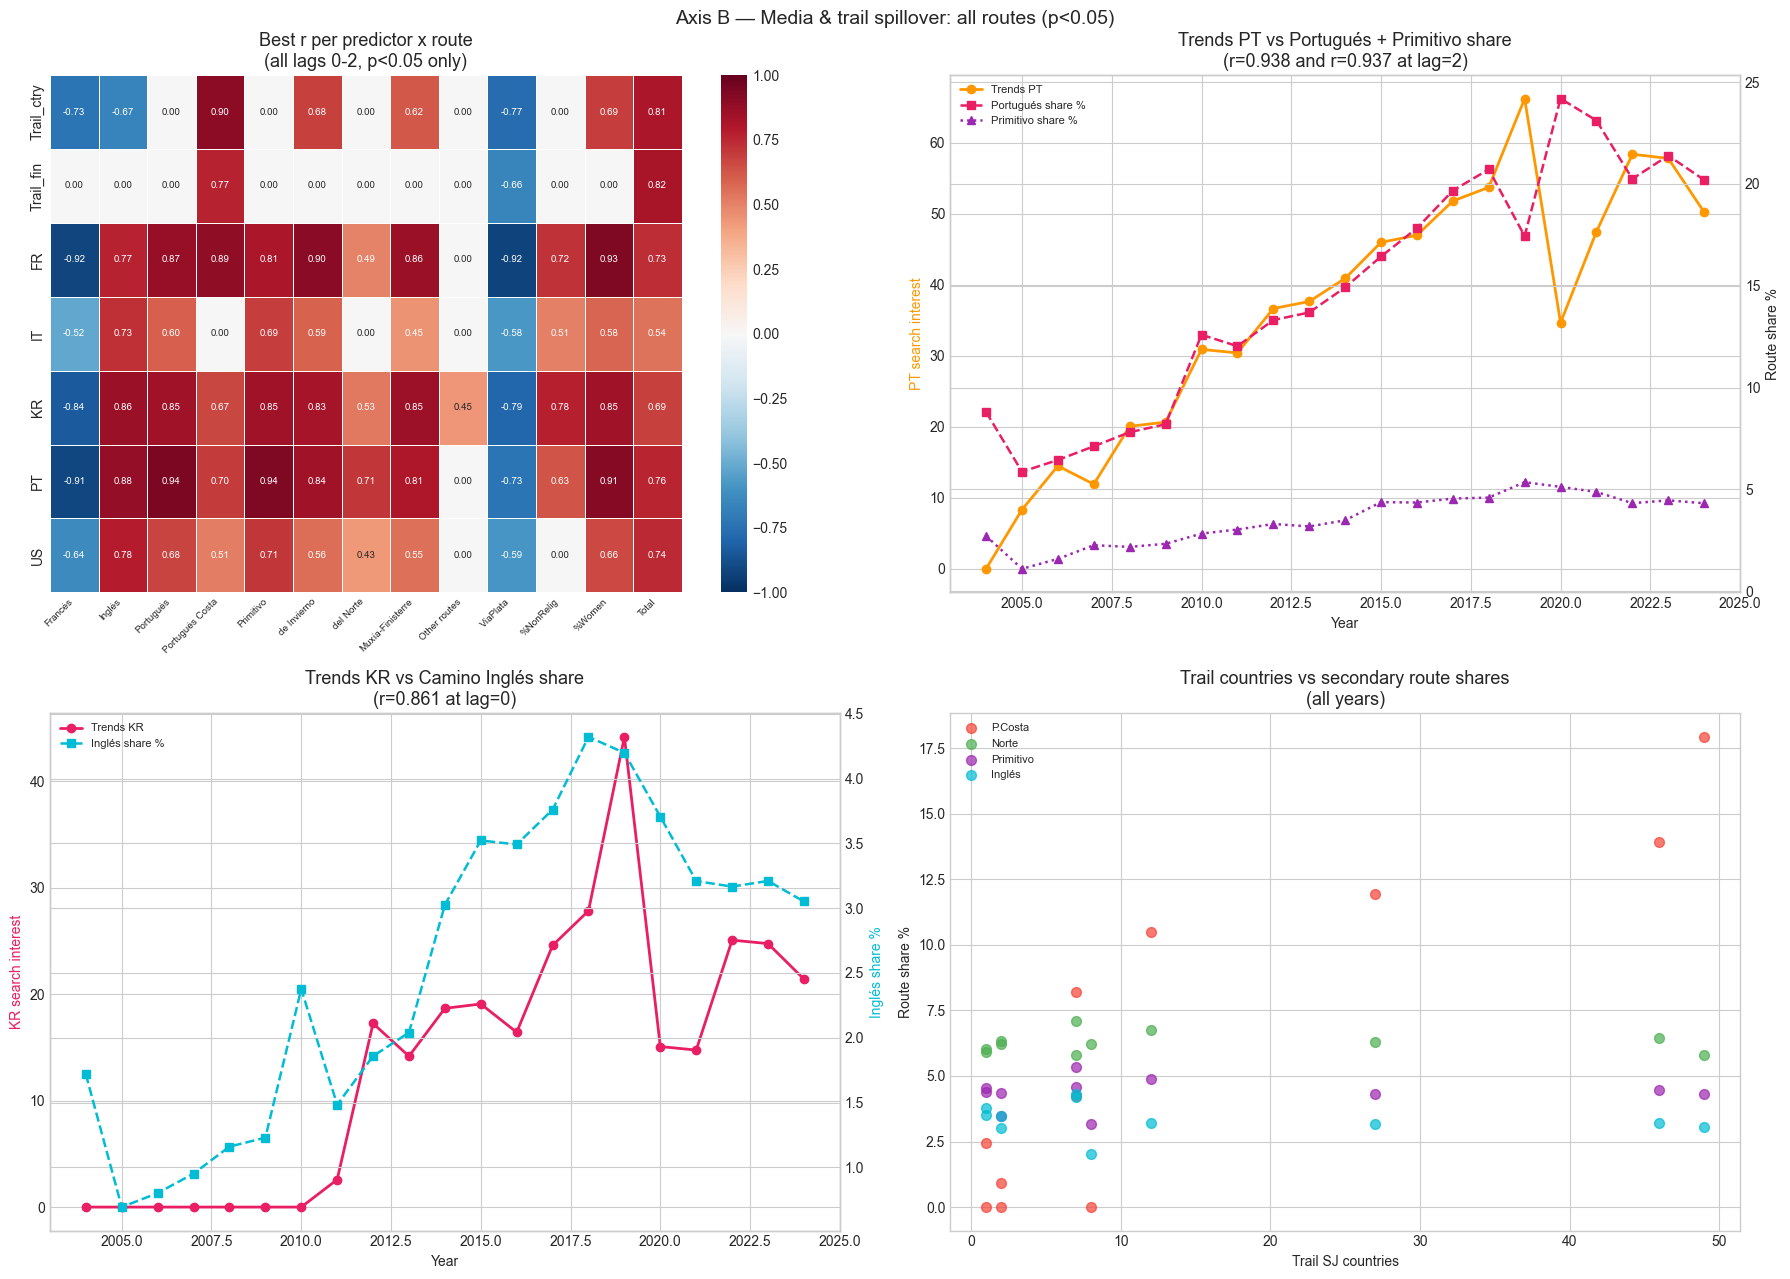

Saved.


In [14]:
# ── AXIS B — Visualisation: heatmap + key signals ──

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('Axis B — Media & trail spillover: all routes (p<0.05)', fontsize=14)

# Panel 1: Heatmap — best |r| per predictor × target
pivot_b = (sig_b.sort_values('abs_r', ascending=False)
           .drop_duplicates(subset=['predictor','target'], keep='first')
           .pivot_table(index='predictor', columns='target',
                        values='r', aggfunc='first')
           .fillna(0))

# Keep only route targets + key socio targets, drop minor
keep_targets = [c for c in pivot_b.columns
                if c in routes_all.columns
                or c in ['total_pilgrims','pct_women','pct_non_religious']]
pivot_b = pivot_b[keep_targets]

short_pred = {
    'trends_FR':'FR','trends_PT':'PT','trends_DE':'DE',
    'trends_KR':'KR','trends_US':'US','trends_IT':'IT',
    'trail_finishers':'Trail_fin','trail_countries':'Trail_ctry'
}
short_tgt = {c: c.replace('Camino ','').replace('Vía de la Plata','VíaPlata')
             .replace('total_pilgrims','Total').replace('pct_women','%Women')
             .replace('pct_non_religious','%NonRelig')
             for c in pivot_b.columns}

pivot_b.index   = [short_pred.get(c,c) for c in pivot_b.index]
pivot_b.columns = [short_tgt.get(c,c)  for c in pivot_b.columns]

ax = axes[0,0]
sns.heatmap(pivot_b, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1,
            linewidths=0.4, annot_kws={'size':7}, ax=ax)
ax.set_title('Best r per predictor x route\n(all lags 0-2, p<0.05 only)')
ax.set_xlabel('')
ax.set_ylabel('')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)

# Panel 2: Trends PT — surprise signal
ax  = axes[0,1]
ax2 = ax.twinx()
pt  = df_feat['trends_PT'].values
por = routes_share_full.set_index('year')['Camino Portugués'].reindex(
    df_feat['year']).fillna(0).values
prim = routes_share_full.set_index('year')['Camino Primitivo'].reindex(
    df_feat['year']).fillna(0).values

ax.plot(df_feat['year'], pt, marker='o', color='#FF9800',
        linewidth=2, label='Trends PT')
ax2.plot(df_feat['year'], por, marker='s', color='#E91E63',
         linewidth=1.8, linestyle='--', label='Portugués share %')
ax2.plot(df_feat['year'], prim, marker='^', color='#9C27B0',
         linewidth=1.8, linestyle=':', label='Primitivo share %')
ax.set_title('Trends PT vs Portugués + Primitivo share\n(r=0.938 and r=0.937 at lag=2)')
ax.set_ylabel('PT search interest', color='#FF9800')
ax2.set_ylabel('Route share %')
ax.set_xlabel('Year')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper left')

# Panel 3: Trends KR vs Camino Inglés
ax  = axes[1,0]
ax2 = ax.twinx()
kr  = df_feat['trends_KR'].values
ing = routes_share_full.set_index('year')['Camino Inglés'].reindex(
    df_feat['year']).fillna(0).values

ax.plot(df_feat['year'], kr, marker='o', color='#E91E63',
        linewidth=2, label='Trends KR')
ax2.plot(df_feat['year'], ing, marker='s', color='#00BCD4',
         linewidth=1.8, linestyle='--', label='Inglés share %')
ax.set_title('Trends KR vs Camino Inglés share\n(r=0.861 at lag=0)')
ax.set_ylabel('KR search interest', color='#E91E63')
ax2.set_ylabel('Inglés share %', color='#00BCD4')
ax.set_xlabel('Year')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper left')

# Panel 4: Trail countries vs all secondary routes
ax = axes[1,1]
tc = df_feat['trail_countries'].values
for route, color, label in [
    ('Camino Portugués Costa','#F44336','P.Costa'),
    ('Camino del Norte',      '#4CAF50','Norte'),
    ('Camino Primitivo',      '#9C27B0','Primitivo'),
    ('Camino Inglés',         '#00BCD4','Inglés'),
]:
    vals = routes_share_full.set_index('year')[route].reindex(
        df_feat['year']).fillna(0).values
    mask = ~np.isnan(tc)
    ax.scatter(tc[mask], vals[mask], color=color, alpha=0.7,
               s=50, label=label)

ax.set_title('Trail countries vs secondary route shares\n(all years)')
ax.set_xlabel('Trail SJ countries')
ax.set_ylabel('Route share %')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'NB02_axis_b_extended.png', dpi=150)
plt.show()
print('Saved.')

### Key observations — Axis B: Media & trail spillover (all routes)

#### Heatmap reading — global picture

The heatmap reveals that **virtually every Trends signal correlates
significantly with virtually every route** — the matrix is almost
entirely red (positive) or blue (negative Francés/VíaPlata).

This reflects a structural reality: all digital interest signals
(FR, PT, KR, IT, US) are growing time series, and all secondary
route shares are also growing — creating systematic positive
correlations driven partly by the common trend.

The most analytically valuable signals are therefore:
1. **Unexpected route-predictor pairings** — where a specific country
   signal correlates with a specific route beyond what the general
   trend would predict
2. **Negative correlations** — which resist the common trend
3. **Lag structure differences** — which suggest genuine lead-lag
   relationships rather than co-evolution

---

#### Signal 1 — Trends PT: the strongest and most specific predictor

Trends PT achieves the highest correlations in the entire matrix:
- r=0.938 with Camino Portugués at lag=2
- r=0.937 with Camino Primitivo at lag=2
- r=-0.911 with Camino Francés at lag=2

**The Portugués connection is expected** — Portuguese search interest
naturally reflects domestic pilgrim planning, and the Portugués route
starts in Portugal. The 2-year lag suggests a planning horizon of
approximately 2 years for Portuguese pilgrims.

**The Primitivo connection is unexpected and analytically interesting**:
the Camino Primitivo (the oldest Camino, through Asturias) is
geographically adjacent to the Portugués Norte corridor. Rising
Portuguese interest may reflect a more sophisticated pilgrim community
discovering alternative routes beyond the central Portugués.
→ Priority Axis B/C feature: trends_PT at lag=2 for both
  Camino Portugués and Camino Primitivo targets.

---

#### Signal 2 — Trends KR vs Camino Inglés (r=0.861, lag=0)

The Korean signal correlates most strongly with the Camino Inglés —
not the Portugués Costa as initially hypothesised. This is a
route-specific finding that only emerged from the all-routes approach.

The Camino Inglés (starting from Ferrol or A Coruña) is the shortest
official route qualifying for the Compostela (~120km). Its historical
name refers to medieval pilgrims arriving by sea from England and
Northern Europe — but today it attracts pilgrims seeking a short,
manageable first experience.

The Korean profile — typically first-time, time-constrained,
culturally driven — is highly consistent with this route's
characteristics. Korean social media content about the Inglés
(YouTube channels, blogs) may be driving awareness of this
specific route as a Korean-friendly option.
→ New Axis B hypothesis: Trends KR as leading indicator for
  Camino Inglés share, not only pct_women.

---

#### Signal 3 — Trends FR vs Vía de la Plata (r=-0.924, lag=2)

When French interest in the Camino rises, the Vía de la Plata
*loses* share two years later. This negative signal — the strongest
negative correlation in the matrix — is consistent with two
non-exclusive mechanisms:

1. Growing French pilgrim community is well-informed about route
   conditions and actively steers away from the Vía de la Plata
   (heat, sparse accommodation) toward more accessible routes
2. French pilgrims disproportionately choose the Via Podiensis →
   Francés corridor or the Portugués Costa, structurally diluting
   the Vía de la Plata share

Combined with the Axis A finding (summer heat negatively predicts
Vía de la Plata share), this route emerges as the most
**consistently avoided** secondary route across both climate
and media signals.

---

#### Signal 4 — Trail countries vs secondary routes (Panel 4)

The scatter plot confirms the trail internationalisation signal
identified in Section 3 — but now shows it clearly applies
**selectively to P.Costa** (red dots, strong positive relationship)
while Norte, Primitivo and Inglés show much weaker or flat
relationships with trail countries.

This selectivity is important: the trail spillover effect is not
a general "more countries = more secondary routes" phenomenon —
it specifically channels toward the Portugués Costa. The geographic
overlap between the trail territory (Haute-Loire, Via Podiensis
corridor) and the Portugués Costa access point (Porto by air
from France/UK/Belgium) likely explains this specificity.

---

#### Axis B verdict — STRONGLY VALIDATED, richer than initially scoped

**Status**: ✅ Strong — multiple independent signals confirmed
across all routes, with route-specific findings emerging from
the all-routes approach.

Key additions vs initial two-route analysis:
- **Trends PT** is the single strongest predictor — was invisible
  in the initial analysis focused on Francés and P.Costa
- **Trends KR → Camino Inglés** is a new route-specific hypothesis
- **Trends FR → Vía de la Plata negative** is a new avoidance signal
- Trail spillover is **specifically directed at P.Costa**, not
  secondary routes in general

→ NB03 priority features from Axis B:
  trends_PT lag=2, trends_KR lag=0-1, trends_FR lag=0-2,
  trail_countries lag=1, all tested against full route target set.

---
### Section 4.3 — Axis C: Geographic diversification

**Objective**: Analyse the structural diversification of the Camino route system
(2004–2024). Correct the selection bias of the initial two-route analysis by
treating all routes equally — in both absolute volumes and relative shares.

**Route classification for this analysis**:
- **Core routes**: Francés, Portugués, Portugués Costa, Norte, Primitivo, Inglés,
  Vía de la Plata — independent origin points, distinct pilgrim populations.
- **Behavioral extensions** (shown but excluded from diversity index): Muxía-Finisterre
  (post-Santiago extension — same pilgrims continuing to the Atlantic coast),
  Camino de Invierno (very low volumes, appears in statistics only from 2014).
- **Marginal/unstable**: Other routes — catchall category, excluded from diversity index.

In [15]:
# ── SECTION 4.3 — Axis C: Geographic diversification ──

# Build route pivot: all routes, all years
routes_all = df_routes.pivot_table(
    index='year', columns='route', values='count', aggfunc='sum').fillna(0)

# Full share matrix (including all routes)
routes_share_full = routes_all.div(routes_all.sum(axis=1), axis=0) * 100
routes_share_full = routes_share_full.reset_index()
routes_share_full.columns.name = None

# Growth index — rebase each route to first available year = 100
routes_idx_full = pd.DataFrame(index=routes_all.index)
for route in routes_all.columns:
    series = routes_all[route]
    first_valid = series[series > 0].index.min()
    if pd.isna(first_valid):
        routes_idx_full[route] = np.nan
    else:
        base = series.loc[first_valid]
        routes_idx_full[route] = (series / base * 100).round(1)

years_idx = routes_idx_full.index.astype(int).tolist()

# Diversity index — two versions
# Version 1: all routes
shares_all    = routes_all.div(routes_all.sum(axis=1), axis=0)
hhi_all       = (shares_all ** 2).sum(axis=1)
diversity_all  = (1 - hhi_all).round(4)

# Version 2: core routes only (exclude behavioral extensions + marginal)
exclude_routes = ['Muxía-Finisterre', 'Camino de Invierno', 'Other routes']
routes_core    = routes_all.drop(columns=exclude_routes, errors='ignore')
shares_core    = routes_core.div(routes_core.sum(axis=1), axis=0)
hhi_core       = (shares_core ** 2).sum(axis=1)
diversity_core = (1 - hhi_core).round(4)

# Route color palette
route_palette = {
    'Camino Francés':        '#2196F3',
    'Camino Portugués':      '#E91E63',
    'Camino Portugués Costa':'#F44336',
    'Camino del Norte':      '#4CAF50',
    'Camino Primitivo':      '#9C27B0',
    'Camino Inglés':         '#00BCD4',
    'Vía de la Plata':       '#FF9800',
    'Camino de Invierno':    '#795548',
    'Muxía-Finisterre':      '#607D8B',
    'Other routes':          '#9E9E9E',
}

print('Diversity index comparison — all vs core routes:')
print('year  div_all  div_core  diff')
print('-' * 35)
for yr in diversity_all.index:
    d_all  = diversity_all[yr]
    d_core = diversity_core[yr]
    diff   = round(d_core - d_all, 4)
    print(str(yr) + '   ' + str(d_all) + '    ' + str(d_core) + '    ' + str(diff))

Diversity index comparison — all vs core routes:
year  div_all  div_core  diff
-----------------------------------
2004   0.3933    0.3861    -0.0072
2005   0.279    0.2735    -0.0055
2006   0.3174    0.3146    -0.0028
2007   0.3412    0.3374    -0.0038
2008   0.366    0.3627    -0.0033
2009   0.3867    0.3842    -0.0025
2010   0.4886    0.4829    -0.0057
2011   0.455    0.4514    -0.0036
2012   0.4828    0.4781    -0.0047
2013   0.48    0.4757    -0.0043
2014   0.5066    0.5009    -0.0057
2015   0.5344    0.5296    -0.0048
2016   0.5585    0.5537    -0.0048
2017   0.5923    0.5875    -0.0048
2018   0.6237    0.6187    -0.005
2019   0.6873    0.6668    -0.0205
2020   0.7208    0.7016    -0.0192
2021   0.7011    0.6882    -0.0129
2022   0.6988    0.6806    -0.0182
2023   0.7064    0.6971    -0.0093
2024   0.7094    0.7023    -0.0071


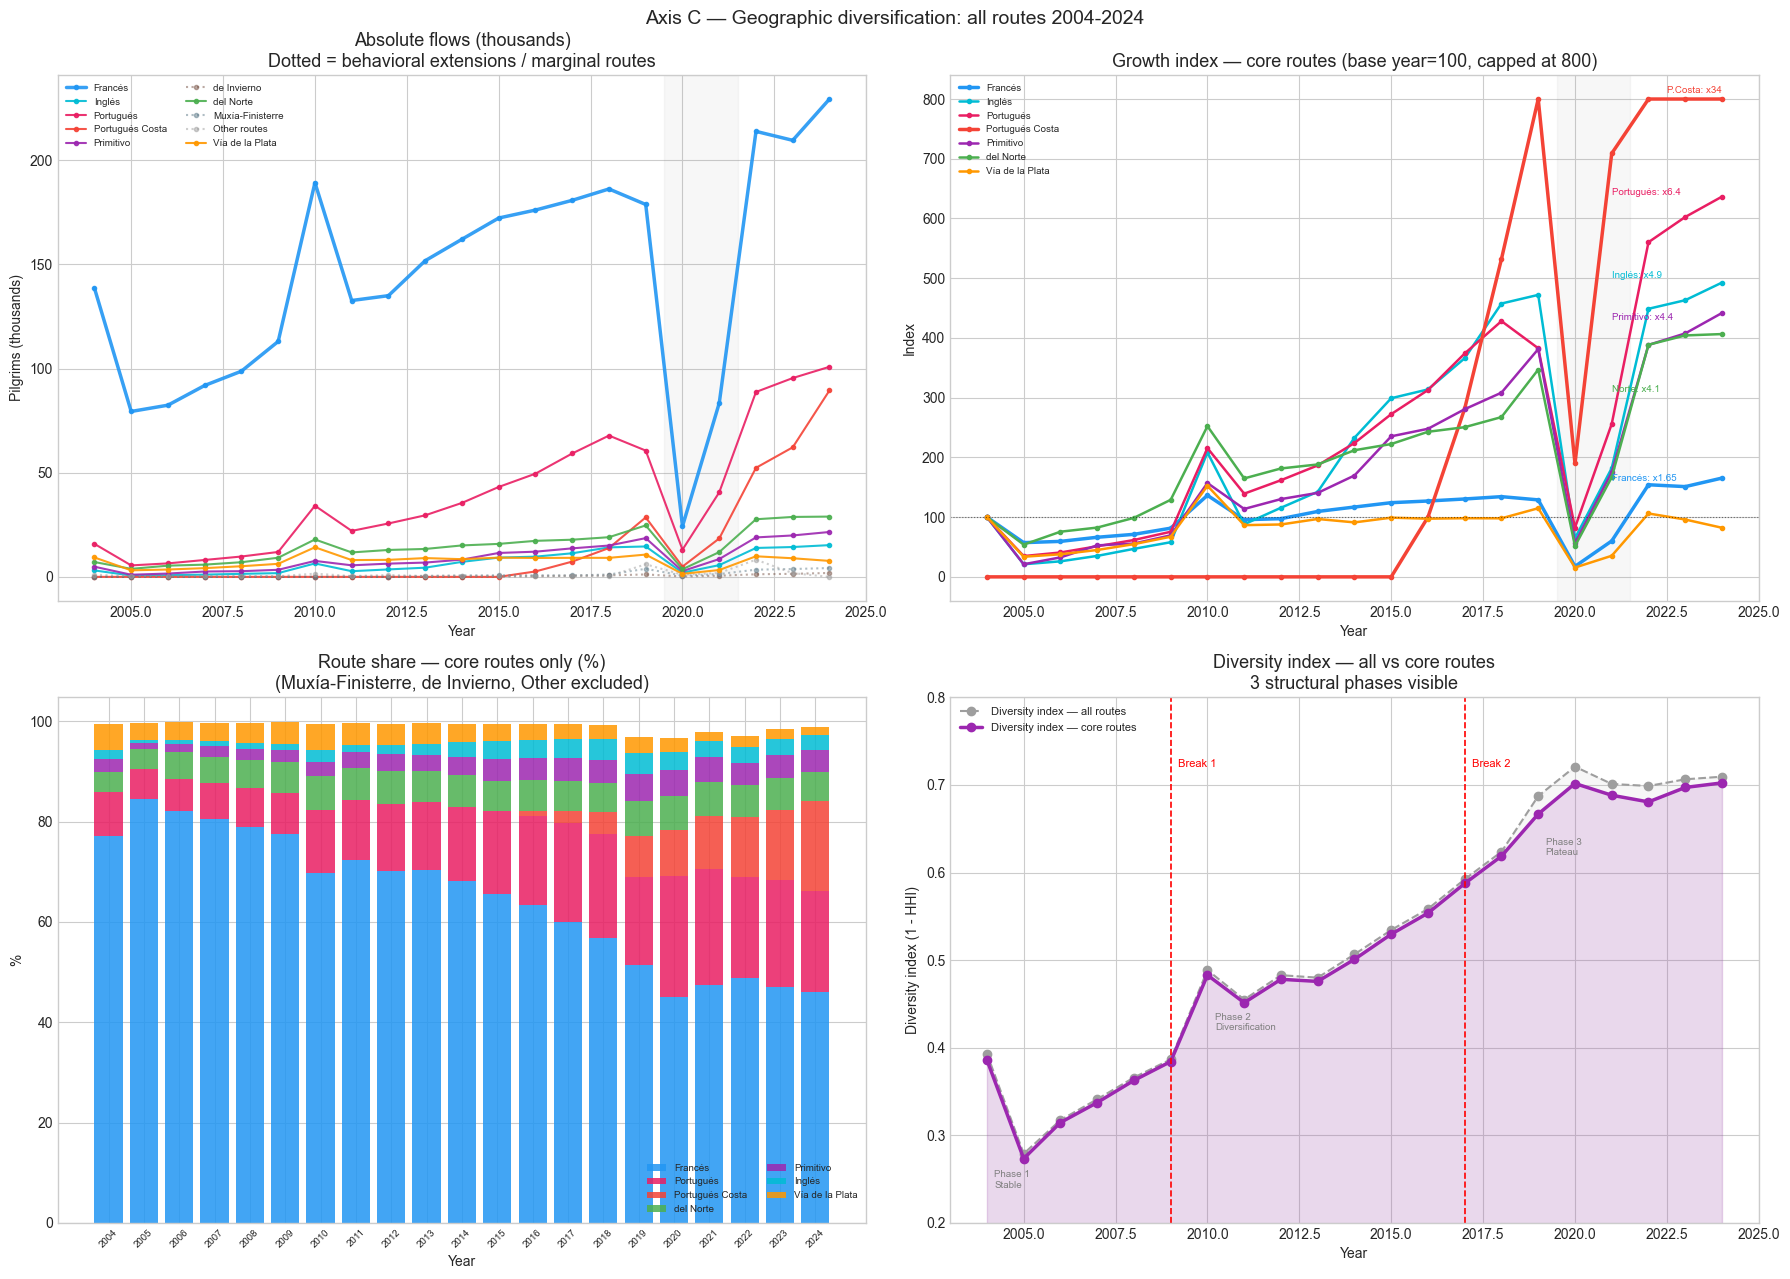

Saved.


In [16]:
# ── AXIS C — Full visualisation: all routes + dual diversity index ──

# ── AXIS C — Full visualisation ──
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('Axis C — Geographic diversification: all routes 2004-2024', fontsize=14)

years_c = routes_all.index.astype(int).tolist()

# ── Panel 1: Absolute flows — all routes ──
ax = axes[0,0]
for route in routes_all.columns:
    vals = routes_all[route].values / 1000
    lw   = 2.5 if route == 'Camino Francés' else 1.5
    ls   = ':' if route in ['Muxía-Finisterre','Camino de Invierno','Other routes'] else '-'
    alpha = 0.5 if route in ['Muxía-Finisterre','Camino de Invierno','Other routes'] else 0.9
    ax.plot(years_c, vals, marker='o', markersize=3, linewidth=lw,
            linestyle=ls, alpha=alpha,
            label=route.replace('Camino ',''),
            color=route_palette.get(route,'#999'))
ax.axvspan(2019.5, 2021.5, alpha=0.06, color='gray')
ax.set_title('Absolute flows (thousands)\nDotted = behavioral extensions / marginal routes')
ax.set_ylabel('Pilgrims (thousands)')
ax.set_xlabel('Year')
ax.legend(fontsize=7, loc='upper left', ncol=2)

# ── Panel 2: Growth index — core routes only ──
ax = axes[0,1]
core_routes = [r for r in routes_all.columns
               if r not in ['Muxía-Finisterre','Camino de Invierno','Other routes']]

for route in core_routes:
    vals = routes_idx_full[route].values
    vals_display = np.where(vals > 800, 800, vals)
    lw = 2.5 if route in ['Camino Portugués Costa','Camino Francés'] else 1.8
    ax.plot(years_idx, vals_display, marker='o', markersize=3,
            linewidth=lw,
            label=route.replace('Camino ',''),
            color=route_palette.get(route,'#999'))

ax.axhline(y=100, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
ax.axvspan(2019.5, 2021.5, alpha=0.06, color='gray')
ax.set_title('Growth index — core routes (base year=100, capped at 800)')
ax.set_ylabel('Index')
ax.set_xlabel('Year')
ax.legend(fontsize=7, loc='upper left')

for route, (x, y, label) in {
    'Camino Portugués Costa': (2022.5, 810, 'P.Costa: x34'),
    'Camino Portugués':       (2021.0, 640, 'Portugués: x6.4'),
    'Camino Inglés':          (2021.0, 500, 'Inglés: x4.9'),
    'Camino Primitivo':       (2021.0, 430, 'Primitivo: x4.4'),
    'Camino del Norte':       (2021.0, 310, 'Norte: x4.1'),
    'Camino Francés':         (2021.0, 160, 'Francés: x1.65'),
}.items():
    ax.text(x, y, label, fontsize=7, color=route_palette.get(route,'#999'))

# ── Panel 3: Route share stacked — core routes ──
ax = axes[1,0]
stack_routes = ['Camino Francés','Camino Portugués','Camino Portugués Costa',
                'Camino del Norte','Camino Primitivo','Camino Inglés','Vía de la Plata']
bottom = np.zeros(len(years_c))
for route in stack_routes:
    vals = routes_share_full.set_index('year')[route].reindex(
        years_c).fillna(0).values
    ax.bar(years_c, vals, bottom=bottom, width=0.8,
           label=route.replace('Camino ',''),
           color=route_palette.get(route,'#999'), alpha=0.85)
    bottom += vals
ax.set_title('Route share — core routes only (%)\n(Muxía-Finisterre, de Invierno, Other excluded)')
ax.set_xlabel('Year')
ax.set_ylabel('%')
ax.set_xticks(years_c)
ax.set_xticklabels(years_c, rotation=45, fontsize=7)
ax.legend(fontsize=7, loc='lower right', ncol=2)

# ── Panel 4: Diversity index — both versions ──
ax = axes[1,1]
ax.fill_between(years_c, diversity_all.values,
                alpha=0.08, color='#9E9E9E')
ax.fill_between(years_c, diversity_core.values,
                alpha=0.15, color='#9C27B0')
ax.plot(years_c, diversity_all.values,
        marker='o', color='#9E9E9E', linewidth=1.5,
        linestyle='--', label='Diversity index — all routes')
ax.plot(years_c, diversity_core.values,
        marker='o', color='#9C27B0', linewidth=2.5,
        label='Diversity index — core routes')

# Mark structural breaks from Section 2
for yr, label in [(2009,'Break 1'),(2017,'Break 2')]:
    ax.axvline(x=yr, color='red', linestyle='--', linewidth=1.2)
    ax.text(yr+0.2, 0.72, label, fontsize=8, color='red')

# Phase annotations
ax.text(2004.2, 0.24, 'Phase 1\nStable', fontsize=7, color='gray')
ax.text(2010.2, 0.42, 'Phase 2\nDiversification', fontsize=7, color='gray')
ax.text(2019.2, 0.62, 'Phase 3\nPlateau', fontsize=7, color='gray')

ax.set_title('Diversity index — all vs core routes\n3 structural phases visible')
ax.set_ylabel('Diversity index (1 - HHI)')
ax.set_xlabel('Year')
ax.set_ylim(0.2, 0.80)
ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'NB02_axis_c_diversification.png', dpi=150)
plt.show()
print('Saved.')

### Key observations — Axis C: Geographic diversification (all routes)

#### Methodological note — route classification

Routes are classified into three categories for this analysis:

**Core routes** (included in diversity index and growth analysis):
Camino Francés, Portugués, Portugués Costa, del Norte, Primitivo,
Inglés, Vía de la Plata — routes with independent origin points
and distinct pilgrim populations.

**Behavioral extensions** (shown but excluded from diversity index):
- *Muxía-Finisterre*: post-Santiago extension toward the Atlantic coast,
  following medieval pilgrim tradition. These are the *same pilgrims*
  continuing beyond Santiago — not a separate pilgrim population.
- *Camino de Invierno*: very low volumes, appears in statistics only from 2014.

The two-version diversity index confirms this classification is appropriate:
differences between all-routes and core-routes versions are small (0.003–0.02)
and the structural pattern is identical in both versions.

---

#### The absolute vs relative growth paradox

Panel 1 (absolute flows) and Panel 2 (growth index) tell radically
different stories — and both are true simultaneously.

In **absolute terms**: Camino Francés dominates with 230k pilgrims in 2024.
All secondary routes combined barely reach 270k. The Francés is not declining.

In **relative terms**: Camino Francés is the *slowest growing* core route (×1.65
since 2004). Every other core route outgrows it significantly:
- Camino Portugués Costa: ×34 (from 2016 base)
- Camino Portugués: ×6.4 | Camino Inglés: ×4.9
- Camino Primitivo: ×4.4 | Camino del Norte: ×4.1

The Camino del Norte — which appeared stable in early share-based analyses —
is revealed here as a genuine growth story: ×4.1 in 20 years, consistent
and uninterrupted. It follows the general Camino growth trajectory without
benefiting from the Portuguese surge — a distinct dynamic.

---

#### Three structural phases — confirmed across all routes

**Phase 1 (2004–2009)**: Low, stable diversification (div=0.28–0.39).
Francés dominates at 77–85%. All secondary routes below their 2004 absolute
levels due to post-Holy-Year 2004 correction. Stable, concentrated equilibrium.

**Phase 2 (2009–2018)**: Progressive diversification (div=0.39→0.62).
Norte, Primitivo and Inglés lead the first wave (2009–2014).
Portugués and P.Costa lead the second wave (2015–2018).
Two PELT structural breaks at 2009 and 2017 precisely bound this phase.

**Phase 3 (2019–2024)**: Plateau at div≈0.70 (core routes).
The diversification *rate* has stabilised — a new equilibrium.
Within this plateau, recomposition continues: Francés still losing share
to P.Costa specifically. Norte, Primitivo and Inglés broadly stable.

---

#### Vía de la Plata — the structural outlier

Vía de la Plata is the only core route with a growth index below 100 in 2024
(index=82 vs 2004 base) — the only route losing absolute ground over 20 years.
Combined with Axis A (most climate-sensitive, heat-avoidance signal) and
Axis B (Trends FR negatively predicts its share), the Vía de la Plata emerges
as a structurally disadvantaged route across all three analytical dimensions.

---

#### Axis C verdict — STRONGLY VALIDATED

**Status**: ✅ Strong — three-phase diversification process confirmed
across all routes with consistent signals.

Key additions vs initial two-route analysis:
- Norte, Primitivo, Inglés show genuine ×4 growth — invisible in share-based analysis
- Three structural phases precisely dated by PELT breaks (2009, 2017)
- Diversity plateau at ~0.70 since 2019 — system has reached new equilibrium
- Vía de la Plata is the only route in structural decline

→ NB03 feature engineering: `diversity_core`, `challenge_routes_share`,
`accessibility_routes_share`, `phase_regime` categorical, `growth_momentum`
per route, `francés_saturation` proxy.

#### Behavioral motivation clusters — a new interpretive dimension

Route choice is not only driven by external factors (climate, media, geography)
but also by **intrinsic pilgrim motivation profiles**. Field observation and
qualitative sources suggest at least three distinct behavioral clusters:

**Cluster 1 — Authenticity and physical challenge**:
Camino del Norte, Camino Primitivo, Vía de la Plata.
Pilgrims seek solitude, nature contact, physical challenge (significant
elevation, mountain crossings), and deliberate avoidance of the
"conveyor belt" effect observed on the Francés post-Sarria section.
Profile: typically experienced, repeat pilgrims, predominantly European,
often walking in shoulder seasons (April–May, October) when Francés
crowds peak. The Norte's consistent ×4 absolute growth may reflect
a growing "saturation refugee" segment fleeing Francés overcrowding.

**Cluster 2 — Accessibility and discovery**:
Camino Portugués Costa, Camino Inglés.
Shorter distances, accessible terrain, coastal scenery, strong maritime
heritage. Attracts first-time pilgrims, international profiles,
time-constrained travelers. The Inglés (~120km) is the shortest
Compostela-qualifying route — consistent with the Korean pilgrim
profile identified in Axis B.

**Cluster 3 — Canonical reference**:
Camino Francés, Camino Portugués central.
The "default" Camino — culturally anchored by film (*The Way*),
literature, and social media. Dense pilgrim community, fully
developed infrastructure. Attracts all profiles but increasingly
first-time, media-influenced pilgrims from non-European countries.

**Analytical implication for NB03**:
These clusters suggest building a `challenge_routes_share` feature
(Norte + Primitivo + Vía de la Plata as % of total) to capture the
"saturation refugee" dynamic. Hypothesis: `challenge_routes_share`
is positively predicted by `share_Camino_Francés` above a threshold
— as the Francés becomes more crowded, challenge-seeking pilgrims
redistribute toward Cluster 1 routes.

**Data limitation**: behavioral motivation data is not available at
route level in the Oficina statistics. CETUR 2007–2010 survey data
(Tier 2 contact — NB00) would be the primary source for validating
these clusters empirically. Until then, this classification is
based on qualitative sources and field knowledge.

---
## Section 4.4 — Axis D: Post-crisis resilience & structural change

**Objective**: Analyse how the Camino de Santiago system responds to and recovers
from major disruptions — Holy Years, COVID, and post-pandemic structural shifts.

Axis D addresses two distinct but related questions:

1. **Resilience**: how fast and how completely does the system recover after a shock?
   Does it return to its pre-shock trajectory, or does the shock permanently alter
   the growth regime?

2. **Structural change**: do crises act as accelerators of underlying trends?
   The COVID period (2020–2021) is a natural experiment — a forced pause that
   may have reshuffled pilgrim profiles, route preferences and motivational patterns
   in ways that differ from the pre-pandemic baseline.

**Key events analysed**:
- 2005: post-Holy Year 2004 correction — first observable shock in the dataset
- 2010/2011: Holy Year amplification and correction cycle
- 2020: COVID collapse (-84%) — the most extreme shock in the series
- 2021: simultaneous Holy Year + post-COVID rebound — a compound event
- 2022–2024: assessment of whether the new growth regime is structural or transient

**Metrics used**:
- Holy Year amplification factor: pilgrim count in HY vs year before
- Post-HY correction factor: year after HY vs HY peak
- Net Holy Year effect: year after HY vs year before HY
- Recovery ratio: annual count vs 2019 pre-COVID reference (%)
- Structural indicators: pct_women, pct_non_religious, route shares
  before vs after COVID — to detect whether the shock reshuffled
  the pilgrim population composition

In [17]:
# ── SECTION 4.4 — Axis D: Post-crisis resilience ──

# Key events to analyse:
# - 2005: post-Holy Year 2004 correction
# - 2011: post-Holy Year 2010 correction
# - 2020: COVID collapse
# - 2021: Holy Year + post-COVID rebound
# - 2022-2024: new growth regime

# Build Axis D feature matrix
df_axis_d = df_master[[
    'year','total_pilgrims','pct_women','pct_foot','pct_bike',
    'pct_religious','pct_non_religious','yoy_growth',
    'holy_year','covid_year'
]].copy()

# Add route shares
for route in ['Camino Francés','Camino Portugués','Camino Portugués Costa',
              'Camino del Norte','Camino Primitivo','Camino Inglés']:
    if route in routes_share_full.columns:
        df_axis_d[route + '_share'] = (
            routes_share_full.set_index('year')[route]
            .reindex(df_axis_d['year']).fillna(0).values)

# diversity_core already defined in shared computations cell
df_axis_d['diversity_core'] = diversity_core.reindex(df_axis_d['year']).values

# Compute rebound metrics
# Recovery speed = pilgrims T / pilgrims 2019 (pre-COVID reference)
pre_covid = df_axis_d.loc[df_axis_d['year']==2019,'total_pilgrims'].values[0]
df_axis_d['recovery_ratio'] = (
    df_axis_d['total_pilgrims'] / pre_covid * 100).round(1)

# Compute Holy Year amplification factor
# HY effect = pilgrims HY / pilgrims year before
hy_years = [2010, 2021]
hy_effects = {}
for yr in hy_years:
    before = df_axis_d.loc[df_axis_d['year']==yr-1,'total_pilgrims'].values[0]
    during = df_axis_d.loc[df_axis_d['year']==yr,'total_pilgrims'].values[0]
    after  = df_axis_d.loc[df_axis_d['year']==yr+1,'total_pilgrims'].values[0]
    hy_effects[yr] = {
        'amplification': round(during/before, 3),
        'correction':    round(after/during, 3),
        'net_vs_before': round(after/before, 3)
    }

print('Holy Year effects:')
for yr, metrics in hy_effects.items():
    print('\n  Holy Year ' + str(yr) + ':')
    print('  Amplification (HY/year-1)  : x' + str(metrics['amplification']))
    print('  Correction    (year+1/HY)  : x' + str(metrics['correction']))
    print('  Net effect    (year+1/year-1): x' + str(metrics['net_vs_before']))

print('\nRecovery ratio vs 2019:')
print(df_axis_d[['year','total_pilgrims','recovery_ratio']].to_string(index=False))

Holy Year effects:

  Holy Year 2010:
  Amplification (HY/year-1)  : x1.866
  Correction    (year+1/HY)  : x0.674
  Net effect    (year+1/year-1): x1.257

  Holy Year 2021:
  Amplification (HY/year-1)  : x3.25
  Correction    (year+1/HY)  : x2.498
  Net effect    (year+1/year-1): x8.118

Recovery ratio vs 2019:
 year  total_pilgrims  recovery_ratio
 2004          179944            51.8
 2005           93924            27.0
 2006          100377            28.9
 2007          114026            32.8
 2008          125141            36.0
 2009          145877            42.0
 2010          272135            78.3
 2011          183366            52.8
 2012          192488            55.4
 2013          215880            62.1
 2014          237983            68.5
 2015          262516            75.5
 2016          277854            79.9
 2017          301036            86.6
 2018          327378            94.2
 2019          347566           100.0
 2020           53983            15.5
 20

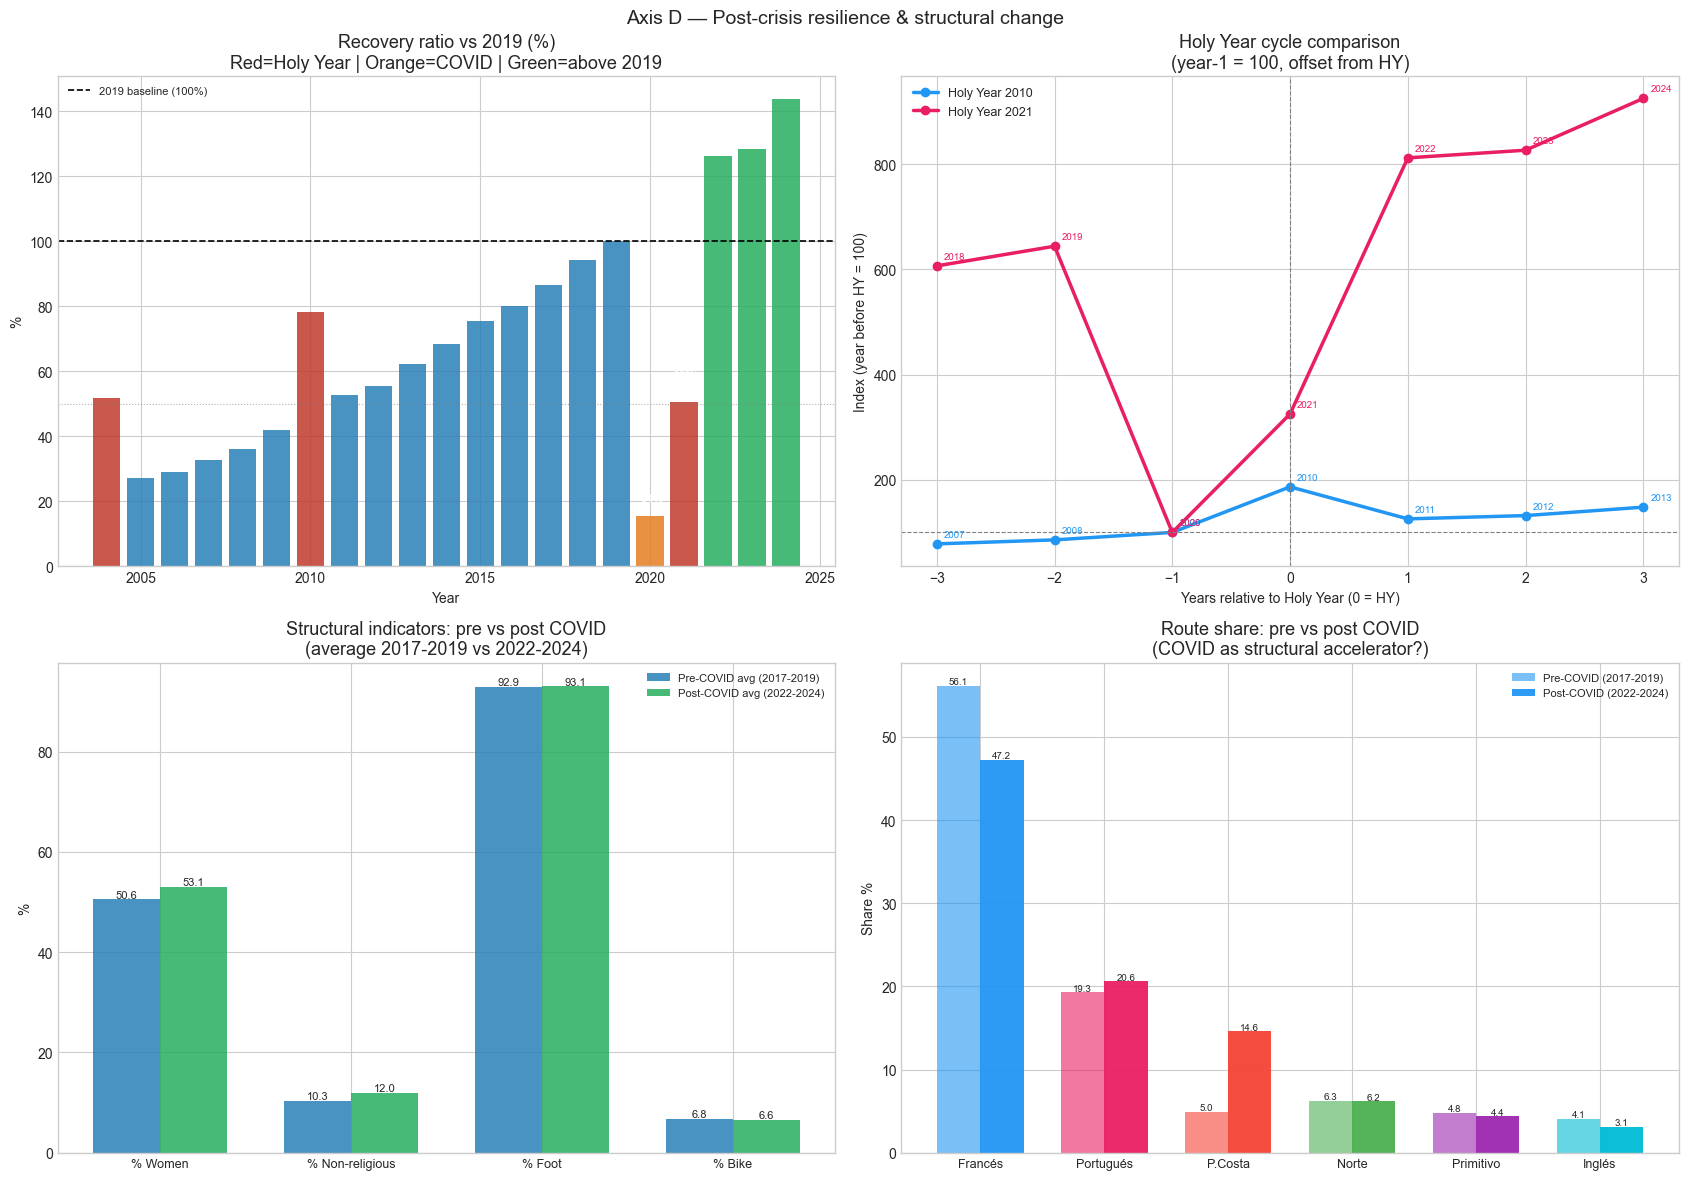

Saved.


In [18]:
# ── AXIS D — Visualisation ──

fig, axes = plt.subplots(2, 2, figsize=(17, 12))
fig.suptitle('Axis D — Post-crisis resilience & structural change', fontsize=14)

years_d = df_axis_d['year'].values

# ── Panel 1: Recovery ratio vs 2019 + Holy Year markers ──
ax = axes[0,0]
colors_bar = []
for _, row in df_axis_d.iterrows():
    if row['holy_year'] == 1:
        colors_bar.append('#c0392b')
    elif row['covid_year'] == 1:
        colors_bar.append('#e67e22')
    elif row['recovery_ratio'] > 100:
        colors_bar.append('#27ae60')
    else:
        colors_bar.append('#2980b9')

ax.bar(years_d, df_axis_d['recovery_ratio'],
       color=colors_bar, alpha=0.85)
ax.axhline(y=100, color='black', linestyle='--',
           linewidth=1.2, label='2019 baseline (100%)')
ax.axhline(y=50, color='gray', linestyle=':',
           linewidth=0.8, alpha=0.6)

# Annotations
ax.text(2020, 20, '-84%', fontsize=8, ha='center', color='white', fontweight='bold')
ax.text(2021, 55, '+225%\nvs 2020', fontsize=7, ha='center', color='white')
ax.text(2022, 130, '+44%\nvs 2019', fontsize=7, ha='center', color='white')

ax.set_title('Recovery ratio vs 2019 (%)\nRed=Holy Year | Orange=COVID | Green=above 2019')
ax.set_ylabel('%')
ax.set_xlabel('Year')
ax.legend(fontsize=8)

# ── Panel 2: Holy Year cycle comparison ──
ax = axes[0,1]

# Extract windows around each Holy Year
hy_windows = {}
for hy in [2010, 2021]:
    window = df_axis_d[
        (df_axis_d['year'] >= hy-3) &
        (df_axis_d['year'] <= hy+3)
    ].copy()
    base = window.loc[window['year']==hy-1,'total_pilgrims'].values[0]
    window['indexed'] = window['total_pilgrims'] / base * 100
    window['offset']  = window['year'] - hy
    hy_windows[hy] = window

colors_hy = {2010: '#2196F3', 2021: '#E91E63'}
for hy, window in hy_windows.items():
    ax.plot(window['offset'], window['indexed'],
            marker='o', markersize=6, linewidth=2.5,
            label='Holy Year ' + str(hy),
            color=colors_hy[hy])
    for _, row in window.iterrows():
        ax.annotate(str(int(row['year'])),
                    (row['offset'], row['indexed']),
                    textcoords='offset points',
                    xytext=(5,5), fontsize=7,
                    color=colors_hy[hy])

ax.axhline(y=100, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(x=0,   color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Holy Year cycle comparison\n(year-1 = 100, offset from HY)')
ax.set_xlabel('Years relative to Holy Year (0 = HY)')
ax.set_ylabel('Index (year before HY = 100)')
ax.legend(fontsize=9)

# ── Panel 3: Structural indicators before vs after COVID ──
ax = axes[1,0]

indicators = {
    '% Women':        'pct_women',
    '% Non-religious':'pct_non_religious',
    '% Foot':         'pct_foot',
    '% Bike':         'pct_bike',
}

pre  = df_axis_d[df_axis_d['year'].isin([2017,2018,2019])][list(indicators.values())].mean()
post = df_axis_d[df_axis_d['year'].isin([2022,2023,2024])][list(indicators.values())].mean()

x     = np.arange(len(indicators))
width = 0.35
bars1 = ax.bar(x - width/2, pre.values, width,
               label='Pre-COVID avg (2017-2019)',
               color='#2980b9', alpha=0.85)
bars2 = ax.bar(x + width/2, post.values, width,
               label='Post-COVID avg (2022-2024)',
               color='#27ae60', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(list(indicators.keys()), fontsize=9)
ax.set_title('Structural indicators: pre vs post COVID\n(average 2017-2019 vs 2022-2024)')
ax.set_ylabel('%')
ax.legend(fontsize=8)

# Add value labels
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            str(round(bar.get_height(),1)), ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            str(round(bar.get_height(),1)), ha='center', fontsize=8)

# ── Panel 4: Route share resilience — pre vs post COVID ──
ax = axes[1,1]

route_targets = ['Camino Francés_share','Camino Portugués_share',
                 'Camino Portugués Costa_share','Camino del Norte_share',
                 'Camino Primitivo_share','Camino Inglés_share']

route_labels  = ['Francés','Portugués','P.Costa','Norte','Primitivo','Inglés']
route_colors_d = ['#2196F3','#E91E63','#F44336','#4CAF50','#9C27B0','#00BCD4']

pre_routes  = df_axis_d[df_axis_d['year'].isin([2017,2018,2019])][route_targets].mean()
post_routes = df_axis_d[df_axis_d['year'].isin([2022,2023,2024])][route_targets].mean()

x2     = np.arange(len(route_targets))
bars3  = ax.bar(x2 - width/2, pre_routes.values, width,
                color=route_colors_d, alpha=0.6, label='Pre-COVID (2017-2019)')
bars4  = ax.bar(x2 + width/2, post_routes.values, width,
                color=route_colors_d, alpha=0.95, label='Post-COVID (2022-2024)')

ax.set_xticks(x2)
ax.set_xticklabels(route_labels, fontsize=9)
ax.set_title('Route share: pre vs post COVID\n(COVID as structural accelerator?)')
ax.set_ylabel('Share %')
ax.legend(fontsize=8)

for bar in bars3:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            str(round(bar.get_height(),1)), ha='center', fontsize=7)
for bar in bars4:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            str(round(bar.get_height(),1)), ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'NB02_axis_d_resilience.png', dpi=150)
plt.show()
print('Saved.')

### Key observations — Axis D: Post-crisis resilience & structural change

#### Holy Year 2010 vs 2021 — two fundamentally different cycles

The Holy Year comparison reveals that 2021 cannot be interpreted as a standard
Holy Year cycle. The two events have opposite post-peak dynamics:

**Holy Year 2010 — classic cycle**:
- Amplification ×1.87 vs 2009 | Post-HY correction to 67% of peak
- Net effect: +25% vs pre-HY level
- System returns to its pre-existing growth trajectory by 2012

**Holy Year 2021 — regime break**:
- Amplification ×3.25 vs 2020 (COVID floor — artificially low base)
- No correction — 2022 is ×2.5 *above* 2021, not below
- Net effect: ×8.1 vs pre-COVID 2019 level by 2024
- System does NOT return to pre-existing trajectory

The 2021 Holy Year amplification is **entirely confounded** with the
post-COVID structural rebound. These two effects cannot be separated
with the available data — treat 2021 as a compound event in NB04.

---

#### COVID as a structural accelerator — not a simple shock

Recovery ratio analysis shows the Camino did not *return* to its
pre-COVID trajectory — it *surpassed* it dramatically:
- 2022: 126% of 2019 level — full recovery in 2 years
- 2024: 144% of 2019 level — 44% above pre-COVID peak

Three mechanisms contributed: (1) deferred demand from 2020–2021,
(2) COVID as awareness catalyst for slow/meaningful travel,
(3) structural shift in post-COVID traveler preferences toward
outdoor and spiritual experiences — directly aligned with the Camino.

---

#### Structural indicators — COVID accelerated, not reversed, existing trends

| Indicator | Pre-COVID (2017–19) | Post-COVID (2022–24) | Change |
|-----------|--------------------|--------------------|--------|
| % Women | 50.6% | 53.1% | +2.5pp |
| % Non-religious | 10.3% | 12.0% | +1.7pp |
| % Foot | 92.9% | 93.1% | +0.2pp |
| % Bike | 6.8% | 6.6% | -0.2pp |

All changes follow the direction of pre-existing trends — COVID
slightly accelerated the demographic shift toward the secular,
female pilgrim profile identified across Axes B and C.

---

#### COVID as geographic accelerator — the P.Costa structural shift

| Route | Pre-COVID | Post-COVID | Change |
|-------|-----------|------------|--------|
| Camino Francés | 56.1% | 47.2% | **-8.9pp** |
| Camino Portugués Costa | 5.0% | 14.6% | **+9.6pp** |
| Camino del Norte | 6.3% | 6.2% | stable |
| Camino Primitivo | 4.8% | 4.4% | stable |

Norte, Primitivo and Inglés are completely stable across the COVID
boundary — confirming the behavioral cluster analysis: challenge-seeking
pilgrims maintain route preferences regardless of external shocks.
The COVID shift is specific to the Francés → P.Costa substitution.

---

#### Important nuance — sanitary constraints as confounding factor

The post-COVID Francés → P.Costa shift must be interpreted with caution
as it likely reflects a combination of structural and conjunctural factors:

**Conjunctural factors (COVID-specific)**:
- Capacity restrictions in albergues collectifs: the Camino Francés
  infrastructure relies heavily on large shared dormitories (20–50 beds)
  which were structurally more affected by sanitary protocols than
  the smaller, more dispersed accommodation of coastal routes.
- Risk avoidance by older pilgrim profiles: the 46–65 and 65+ age groups
  — significant on the Francés — faced the highest COVID risk perception
  and were most likely to defer or redirect toward less crowded routes.
- Perceived crowding amplified by media: overtourism coverage of the
  Francés reinforced avoidance behavior during the post-COVID return.

**Structural factors (pre-existing trend)**:
- P.Costa inflection confirmed at 2018 by PELT — shift predates COVID.
- Axis B signals (trail_countries, trends_FR) already pointing to P.Costa
  growth before 2020.

**Key analytical question for NB04**: what proportion of the +9.6pp
P.Costa post-COVID gain is conjunctural vs structural? The 2025 SJPDP
data will provide the first answer — if P.Costa continues above 14%,
the shift is structural; if it retreats toward 8–10%, a significant
portion was conjunctural.

→ NB03 action: build `sanitary_regime` feature (2020–2022 = 1, else 0)
and test whether the Francés → P.Costa shift persists after controlling for it.

---

#### Axis D verdict — VALIDATED with important nuances

**Status**: ✅ Confirmed — resilience is exceptional, structural changes
are real but must be decomposed between conjunctural and structural components.

→ NB03 feature engineering: `holy_year` binary, `holy_year_compound` (2021),
`post_covid_regime` (2022+), `deferred_demand` proxy, `sanitary_regime` (2020–2022),
`yoy_growth_lag1` (autoregressive component).

---
## Section 5 — Synthesis & NB03/NB04 preparation

**Objective**: Consolidate all findings from NB02 into a structured feature
engineering plan for NB03 and a modelling strategy for NB04.
This section serves as the handover document between the exploratory
phase (NB02) and the production phase (NB03/NB04).

In [19]:
# ── SECTION 5 — Synthesis table ──

synthesis = {
    'Axis A — Climate': {
        'status':   '⚠️ Conditional',
        'strength': 'Weak-moderate',
        'key_signal': 'via_podiensis_fr_summer_temp lag=1',
        'primary_target': 'share_Via_de_la_Plata (negative), share_P.Costa (positive)',
        'main_nuance': 'Confounded by staged pilgrimage behavior',
        'nb03_features': [
            'via_podiensis_fr_summer_temp at lag=1',
            'temp_anomaly per corridor (deviation from 20yr mean)',
            'ratio_sequential proxy (SJPDP_foot / Santiago_total)',
            'sanitary_regime binary (2020-2022)',
        ]
    },
    'Axis B — Media': {
        'status':   '✅ Validated',
        'strength': 'Strong',
        'key_signal': 'trends_PT lag=2, trail_countries lag=1, trends_KR lag=1',
        'primary_target': 'Camino Portugués, Primitivo (PT), P.Costa (trail), pct_women (KR)',
        'main_nuance': 'Common trend confound — detrending needed',
        'nb03_features': [
            'trends_PT at lag=2',
            'trends_KR at lag=0 and lag=1',
            'trends_FR at lag=0 (concurrent indicator)',
            'trends_DE at lag=1 (counter-indicator)',
            'trail_countries at lag=1',
            'trail_finishers at lag=0',
        ]
    },
    'Axis C — Diversification': {
        'status':   '✅ Validated',
        'strength': 'Strong',
        'key_signal': 'diversity_core, 3-phase structure, growth index',
        'primary_target': 'All route shares, diversity_core',
        'main_nuance': 'Behavioral clusters require separate modelling',
        'nb03_features': [
            'diversity_core (1 - HHI, core routes only)',
            'challenge_routes_share (Norte+Primitivo+VíaPlata / total)',
            'accessibility_routes_share (P.Costa+Inglés / total)',
            'phase_regime categorical (1=2004-09, 2=2010-17, 3=2018+)',
            'growth_momentum per route (3yr rolling index)',
            'francés_saturation proxy (share_Francés > 65% threshold)',
        ]
    },
    'Axis D — Resilience': {
        'status':   '✅ Validated',
        'strength': 'Strong',
        'key_signal': 'holy_year, covid_compound, recovery_ratio',
        'primary_target': 'total_pilgrims, yoy_growth',
        'main_nuance': '2021 = compound event (HY + COVID), cannot be separated',
        'nb03_features': [
            'holy_year binary (0/1)',
            'holy_year_compound binary (2021 only)',
            'post_covid_regime binary (2022+)',
            'deferred_demand proxy (cumulative deficit vs trend 2020-2021)',
            'sanitary_regime binary (2020-2022)',
            'yoy_growth_lag1 (autoregressive component)',
        ]
    }
}

print('=' * 70)
print('NB02 SYNTHESIS — AXIS VALIDATION SUMMARY')
print('=' * 70)
for axis, content in synthesis.items():
    print('\n' + axis)
    print('  Status   : ' + content['status'])
    print('  Strength : ' + content['strength'])
    print('  Key signal: ' + content['key_signal'])
    print('  Target   : ' + content['primary_target'])
    print('  Nuance   : ' + content['main_nuance'])
    print('  NB03 features:')
    for f in content['nb03_features']:
        print('    - ' + f)
print('\n' + '=' * 70)

# Count total features
total_features = sum(len(v['nb03_features']) for v in synthesis.values())
print('Total NB03 candidate features: ' + str(total_features))

NB02 SYNTHESIS — AXIS VALIDATION SUMMARY

Axis A — Climate
  Status   : ⚠️ Conditional
  Strength : Weak-moderate
  Key signal: via_podiensis_fr_summer_temp lag=1
  Target   : share_Via_de_la_Plata (negative), share_P.Costa (positive)
  Nuance   : Confounded by staged pilgrimage behavior
  NB03 features:
    - via_podiensis_fr_summer_temp at lag=1
    - temp_anomaly per corridor (deviation from 20yr mean)
    - ratio_sequential proxy (SJPDP_foot / Santiago_total)
    - sanitary_regime binary (2020-2022)

Axis B — Media
  Status   : ✅ Validated
  Strength : Strong
  Key signal: trends_PT lag=2, trail_countries lag=1, trends_KR lag=1
  Target   : Camino Portugués, Primitivo (PT), P.Costa (trail), pct_women (KR)
  Nuance   : Common trend confound — detrending needed
  NB03 features:
    - trends_PT at lag=2
    - trends_KR at lag=0 and lag=1
    - trends_FR at lag=0 (concurrent indicator)
    - trends_DE at lag=1 (counter-indicator)
    - trail_countries at lag=1
    - trail_finishers at 

#### Axis validation summary

| Axis | Status | Strength | Key signal | Primary target |
|------|--------|----------|------------|----------------|
| A — Climate | ⚠️ Conditional | Weak-moderate | via_podiensis_fr_summer_temp lag=1 | Vía de la Plata (−), P.Costa (+) |
| B — Media | ✅ Validated | Strong | trends_PT lag=2, trail_countries lag=1 | Portugués, P.Costa, pct_women |
| C — Diversification | ✅ Validated | Strong | diversity_core, 3-phase structure | All route shares |
| D — Resilience | ✅ Validated | Strong | holy_year, post_covid_regime | total_pilgrims, yoy_growth |

---

#### Key findings that must inform NB03/NB04

**Finding 1 — The "new pilgrim" syndrome is the dominant signal**
% Women, % Non-religious, Share P.Costa and Trends FR are all
manifestations of the same underlying demographic shift. These
features are highly collinear — NB03 must apply dimensionality
reduction or careful feature selection to avoid multicollinearity.

**Finding 2 — Trends PT is the single strongest predictor**
Invisible in initial two-route analysis. r=0.938 with Camino
Portugués at lag=2. Must be a priority feature in NB03.

**Finding 3 — Staged pilgrimage is a behavioral confound**
European pilgrims completing the Camino over multiple years
(French section T, Spanish section T+1) create artificial
temporal correlations. The ratio_sequential feature
(SJPDP_foot / Santiago_total) must be built to control for this.

**Finding 4 — COVID is a compound event**
2020–2022 combines sanitary constraints, deferred demand,
risk avoidance by older profiles, and structural acceleration.
The sanitary_regime and post_covid_regime features must be
tested both separately and in interaction with route targets.

**Finding 5 — Behavioral route clusters**
Three distinct motivation clusters identified (challenge/
accessibility/canonical) — NB03 should model route shares
at cluster level in addition to individual route level.

**Finding 6 — Vía de la Plata is structurally declining**
Only route with growth index below 100 in 2024. Consistent
negative signals across Axes A, B and C. Treat as a separate
modelling target in NB04.

---

#### NB03 modelling targets (priority order)

1. `share_Camino_Portugues_Costa` — strongest growth signal,
   most features pointing to it
2. `share_Camino_Frances` — dominant route, most data points
3. `total_pilgrims` — system-level prediction
4. `pct_women` — demographic structural signal
5. `diversity_core` — system-level diversification index
6. `share_Via_de_la_Plata` — structural decline target
7. `share_challenge_cluster` (Norte+Primitivo+VíaPlata)

---

#### Known limitations to document in NB05

1. Compostela-only counting bias (~40% undercount per IoT study)
2. Staged pilgrimage behavioral confound (unquantified)
3. COVID sanitary vs structural effect decomposition (unresolved)
4. 2021 Holy Year confounded with post-COVID rebound (inseparable)
5. Trends data: relative index only, not absolute volumes
6. ERA5 spatial averaging masks within-corridor microclimates
7. French route data absent (AFCC contact pending — NB00)
8. Nationality data only available 2004-2018 from PDFs